# Proyecto – Limpieza y Verificación del dataset "train'3.csv"
### Ingeniería Financiera  

El objetivo de este notebook es obtener un dataset robusto, consistente y listo para modelado

## Parte 1: Limpieza de Datos

En esta sección se realiza:

- Conversión de variables al tipo correcto
- Identificación de valores inválidos
- Tratamiento de datos faltantes
- Generación de variables finales limpias


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

In [2]:
df = pd.read_csv('train-3.csv')
df.head()

C:\Users\raulo\AppData\Local\Temp\ipykernel_42476\1322532381.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train-3.csv')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


Se utilizó df.info() para revisar la estructura general del dataset, verificar los tipos de datos de cada variable y detectar posibles valores faltantes antes de iniciar el proceso de limpieza.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

### Limpieza y Corrección de la Variable Age
Se identificó que la variable Age presenta inconsistencias en sus valores. Aunque algunos registros coinciden correctamente, existen otros que no mantienen coherencia, lo que sugiere posibles errores en la captura o almacenamiento de los datos.

Además, la variable está registrada como tipo object, cuando por su naturaleza debería ser numérica. Por ello, fue necesario convertirla al formato adecuado y posteriormente validar sus valores antes de continuar con el análisis.

#### 1. Análisis Exploratorio y Hallazgos
**a) Estructura del dataset**

Cada Customer_ID aparece en 8 registros (uno por mes).
Dado que la edad de una persona no cambia mensualmente, se espera que este valor sea prácticamente constante dentro de cada bloque de 8 observaciones.

Esto nos permite utilizar consistencia intra-cliente como criterio para detectar errores.

**b) Distribución global de Age**

Tras convertir la variable a formato numérico, se observaron valores claramente imposibles, tales como:

-500

8698

El percentil 99 de la distribución es 4112, lo que confirma la existencia de corrupción en el campo.

Definiendo como válidas las edades en el rango [18, 100], se encontró que:

8.482% de las filas presentan edades inválidas (Age < 18 o Age > 100).

**c) Consistencia por cliente**

El dataset contiene:

100,000 filas

12,500 clientes (100,000 / 8 meses)

Al agrupar por Customer_ID y contar valores únicos de edad:

La mayoría de los clientes presenta entre 1 y 2 valores únicos.

Sin embargo, existen casos con hasta 4–6 valores distintos.

25.216% de los clientes tienen al menos un valor inválido dentro de sus 8 registros.

Ejemplo típico de inconsistencia:

7 meses con edad 23

1 mes con edad -500

Esto confirma errores puntuales dentro de bloques que deberían ser estables.

In [4]:
age_num = pd.to_numeric(
    df["Age"].astype(str).str.strip().str.replace("_","", regex=False),
    errors="coerce"
)

desc = age_num.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99])
invalid_rate = ((age_num < 18) | (age_num > 100)).mean()

print(desc)
print("Invalid rate (Age<18 or Age>100):", invalid_rate)

count    100000.000000
mean        110.649700
std         686.244717
min        -500.000000
1%           14.000000
5%           16.000000
25%          24.000000
50%          33.000000
75%          42.000000
95%          53.000000
99%        4112.070000
max        8698.000000
Name: Age, dtype: float64
Invalid rate (Age<18 or Age>100): 0.08482


In [5]:
df_age = df[["Customer_ID","Month","Age"]].copy()
df_age["Age_num"] = pd.to_numeric(
    df_age["Age"].astype(str).str.strip().str.replace("_","", regex=False),
    errors="coerce"
)

g = df_age.groupby("Customer_ID")["Age_num"]

age_profile = g.agg(
    n_rows="size",
    n_unique=lambda s: s.nunique(dropna=True),
    min_age="min",
    max_age="max",
    mode_age=lambda s: s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else np.nan,
    mode_freq=lambda s: (s.value_counts(dropna=True).iloc[0] if not s.value_counts(dropna=True).empty else 0),
)

age_profile["has_invalid"] = (age_profile["min_age"] < 18) | (age_profile["max_age"] > 100)
age_profile["mode_share"] = age_profile["mode_freq"] / age_profile["n_rows"]

print(age_profile["has_invalid"].mean())
print(age_profile["n_unique"].value_counts().head(10))

0.25216
n_unique
2    6789
1    4193
3    1397
4     115
5       5
6       1
Name: count, dtype: int64


In [6]:
bad_clients = age_profile.query("has_invalid or n_unique>=4 or (max_age-min_age)>=30") \
                         .sort_values(["has_invalid","n_unique","max_age"], ascending=[False,False,False])

print(bad_clients.head(20))

             n_rows  n_unique  min_age  max_age  mode_age  mode_freq  \
Customer_ID                                                            
CUS_0x6fa7        8         6     -500     8049        33          3   
CUS_0xb5d7        8         5       21     8421        22          4   
CUS_0x69a2        8         5     -500     7444        25          3   
CUS_0x72b0        8         5       31     5907        31          3   
CUS_0x6794        8         5     -500     5717        42          4   
CUS_0x3382        8         5     -500     3145        26          4   
CUS_0x997         8         4       25     8678        26          5   
CUS_0x87a2        8         4       28     8662        28          5   
CUS_0x8a64        8         4     -500     8616        31          5   
CUS_0x4981        8         4     -500     8608        41          3   
CUS_0x461f        8         4     -500     8561        54          3   
CUS_0x5764        8         4     -500     8520        22       

#### 2. Decisiones de Limpieza

El objetivo fue minimizar la pérdida de información y evitar eliminar registros completos.

Se adoptó la siguiente estrategia:

**Regla de validez**

Se marcaron como NaN todas las edades fuera del rango:

$18 ≤ Age ≤ 100$

Esto elimina valores estructuralmente imposibles sin borrar filas.

**Corrección por mayoría (Majority Vote)**

Para cada Customer_ID, se imputó la edad utilizando:

El modo (valor más frecuente) entre las edades válidas del cliente.

Esta estrategia:

Corrige outliers como -500 o 8000+

Preserva la coherencia intra-cliente

Evita imputaciones arbitrarias

**Fallback para casos extremos**

En aproximadamente 5.504% de los clientes, todas las edades resultaron inválidas.

En estos casos, se imputó utilizando:

La mediana global de las edades válidas del dataset.

Esto permite conservar los registros sin introducir sesgos extremos.

In [7]:
df_raw = df                      # referencia al original (no lo modifiques)
df_work = df_raw.copy(deep=True) # “sandbox” para limpieza

In [8]:
# ========= Limpieza Age en df_work =========
df_age = df_work[["Customer_ID", "Month", "Age"]].copy()

df_age["Age_num"] = pd.to_numeric(
    df_age["Age"].astype(str).str.strip().str.replace("_", "", regex=False),
    errors="coerce"
)



LOW, HIGH = 18, 100
df_age.loc[(df_age["Age_num"] < LOW) | (df_age["Age_num"] > HIGH), "Age_num"] = np.nan

mode_by_cust = df_age.groupby("Customer_ID")["Age_num"].agg(
    lambda s: s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else np.nan
)

df_age["Age_mode"] = df_age["Customer_ID"].map(mode_by_cust)

global_median_age = df_age["Age_num"].median()
df_age["Age_final"] = df_age["Age_mode"].fillna(global_median_age)

# Evitar duplicación si re-ejecutas
if "Age_final" in df_work.columns:
    df_work = df_work.drop(columns=["Age_final"])

df_work = df_work.merge(
    df_age[["Customer_ID", "Month", "Age_final"]],
    on=["Customer_ID", "Month"],
    how="left",
    validate="one_to_one"
)

# ========= Checks =========
post_invalid_rate = ((df_work["Age_final"] < LOW) | (df_work["Age_final"] > HIGH)).mean()
print("Invalid rate AFTER:", post_invalid_rate)
print(df_work["Age_final"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

age_num_raw = pd.to_numeric(
    df_work["Age"].astype(str).str.strip().str.replace("_", "", regex=False),
    errors="coerce"
)
age_num_valid = age_num_raw.mask((age_num_raw < LOW) | (age_num_raw > HIGH))
pct_corrected = (age_num_valid.isna() | (age_num_valid != df_work["Age_final"])).mean()

cust_has_any_valid = df_age.groupby("Customer_ID")["Age_num"].apply(lambda s: s.notna().any()).mean()

print("Pct filas corregidas o imputadas:", pct_corrected)
print("Pct clientes con AL MENOS una edad válida:", cust_has_any_valid)
print("Pct clientes sin ninguna edad válida:", 1 - cust_has_any_valid)

Invalid rate AFTER: 0.0
count    100000.00000
mean         34.29872
std           9.85935
min          18.00000
1%           18.00000
5%           19.00000
25%          26.00000
50%          34.00000
75%          42.00000
95%          52.00000
99%          55.00000
max          56.00000
Name: Age_final, dtype: float64
Pct filas corregidas o imputadas: 0.23467
Pct clientes con AL MENOS una edad válida: 0.94496
Pct clientes sin ninguna edad válida: 0.05503999999999998


Número de clientes: 12500


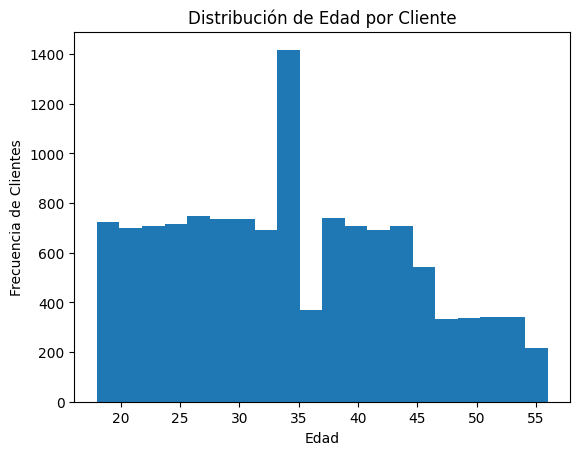

In [9]:
# Tomar una sola edad por cliente
age_per_customer = (
    df_work[["Customer_ID", "Age_final"]]
    .drop_duplicates(subset="Customer_ID")
)

# Verificación opcional
print("Número de clientes:", age_per_customer.shape[0])

# Plot
plt.figure()
plt.hist(age_per_customer["Age_final"], bins=20)

plt.title("Distribución de Edad por Cliente")
plt.xlabel("Edad")
plt.ylabel("Frecuencia de Clientes")

plt.show()

#### 3. Resultado Final

Como resultado del proceso:

- Se corrigieron edades corruptas utilizando consistencia intra-cliente.
- No se eliminaron filas del dataset.
- Se obtuvo una variable Age_final limpia y lista para modelado.

### Limpieza de la Variable Annual_Income
**Contexto y Objetivo**

El modelo a desarrollar es de tipo clásico/lineal (similar al enfoque de Altman), basado en una combinación ponderada de variables explicativas:

$$ 𝑆𝑐𝑜𝑟𝑒=𝛽_0+𝛽_1𝑋_1+𝛽_2𝑋_2+⋯ $$


En este tipo de modelos, la escala, distribución y estabilidad estadística de las variables numéricas son fundamentales.

A diferencia de modelos no lineales, los modelos lineales son sensibles a valores extremos y a distribuciones altamente sesgadas.

Un número pequeño de valores extremos puede:
- Inflar la media y la varianza,
- Volver inestables los coeficientes \(\beta\),
- Hacer que el score quede “dominado” por pocos registros,
- Deteriorar la capacidad predictiva fuera de muestra.

Por eso, antes de entrenar, necesitamos asegurar que `Annual_Income` esté:
1) correctamente convertido a numérico,  
2) libre de valores inválidos (missing/≤0), y  
3) sin outliers extremos que distorsionen el ajuste lineal.

#### Paso 1 — Conversión robusta a numérico
`Annual_Income` venía como `object`. Primero lo convertimos a `float` (creando `Annual_Income_num`), limpiando formatos (por ejemplo, underscores o separadores) y forzando `errors="coerce"` para que cualquier valor no interpretable se vuelva `NaN`.

**Resultado observado:**
- `Pct inválido básico (<=0 o NaN): 0.0`  
Esto indica que **todos los registros** tienen un ingreso anual positivo y parseable.  
No necesitamos imputación por missing en esta variable.

In [10]:
#df_work = df.copy(deep=True)  # seguridad

# --- 1) Parse robusto de Annual_Income (object -> float) ---
inc_raw = df_work["Annual_Income"].astype(str).str.strip()

# Normaliza placeholders comunes
inc_raw = inc_raw.replace({
    "nan": np.nan,
    "None": np.nan,
    "": np.nan,
    "__10000__": np.nan,
    "__-333333333333333333333333333__": np.nan
})

# Remueve underscores tipo "12345_" (si existiera) y separadores raros
inc_raw = inc_raw.str.replace("_", "", regex=False)
inc_raw = inc_raw.str.replace(",", "", regex=False)

df_work["Annual_Income_num"] = pd.to_numeric(inc_raw, errors="coerce")


#### Paso 2 — Diagnóstico de distribución y detección de extremos
Se calculó la distribución con percentiles finos. Los resultados relevantes fueron:

- P99 = 179,987  
- P99.9 = 21,752,126  
- max = 24,198,062  
- \(\text{Pct} > \text{P99.9} = 0.001\) (0.1% ≈ 100 filas)

Interpretación:
- La masa principal del ingreso está por debajo de ~180k (P99).
- Existe una **cola derecha extremadamente pesada**: el salto de P99 (≈180k) a P99.9 (≈21.7M) es enorme.
- Esos pocos valores extremos inflan:
  - `mean = 176,415`
  - `std = 1,429,618`
  aunque la mayoría del portafolio está muy por debajo de esos niveles.

Conclusión:
- No hay un problema de datos faltantes.
- El problema relevante es **la presencia de outliers altos extremos**.

In [11]:
# --- 2) Distribución global ---
desc = df_work["Annual_Income_num"].describe(percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999])
print(desc)

# --- 3) Reglas mínimas de validez (sin asumir demasiado) ---
# Ingreso anual debe ser > 0 (0 o negativo es inválido en este dataset)
invalid_basic = (df_work["Annual_Income_num"] <= 0) | (df_work["Annual_Income_num"].isna())
print("Pct inválido básico (<=0 o NaN):", invalid_basic.mean())
# Detecta extremos sin hardcode: umbral superior = percentil 99.9
p999 = df_work["Annual_Income_num"].quantile(0.999)
print("P99.9 Annual_Income:", p999)

# % filas por arriba del p99.9 (potenciales outliers)
print("Pct > P99.9:", (df_work["Annual_Income_num"] > p999).mean())

count    1.000000e+05
mean     1.764157e+05
std      1.429618e+06
min      7.005930e+03
0.1%     7.056405e+03
1%       7.535997e+03
5%       9.743510e+03
25%      1.945750e+04
50%      3.757861e+04
75%      7.279092e+04
95%      1.345333e+05
99%      1.799873e+05
99.9%    2.175213e+07
max      2.419806e+07
Name: Annual_Income_num, dtype: float64
Pct inválido básico (<=0 o NaN): 0.0
P99.9 Annual_Income: 21752126.01800004
Pct > P99.9: 0.001


#### Paso 3 — Consistencia por cliente (`Customer_ID`)
Como cada cliente aparece en varios meses, revisamos estabilidad intra-cliente con `n_unique`:

- `n_unique = 1`: 11,535 clientes  
- `n_unique = 2`: 933  
- `n_unique = 3`: 30  
- `n_unique = 4`: 2  
- `Pct clientes con algún NaN: 0.0`

Interpretación:
- La mayoría de clientes tienen ingreso anual estable.
- No hay `NaN` por cliente.
- Por lo tanto, **no se requiere majority vote** (como en Age) para resolver faltantes.

En este punto, el enfoque más simple y conservador es corregir únicamente **los outliers extremos**.

In [12]:
g = df_work.groupby("Customer_ID")["Annual_Income_num"]

income_profile = g.agg(
    n_rows="size",
    n_unique=lambda s: s.nunique(dropna=True),
    min_inc="min",
    max_inc="max",
    mode_inc=lambda s: s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else np.nan,
    mode_freq=lambda s: (s.value_counts(dropna=True).iloc[0] if not s.value_counts(dropna=True).empty else 0),
)

income_profile["mode_share"] = income_profile["mode_freq"] / income_profile["n_rows"]

print(income_profile["n_unique"].value_counts().head(10))
print("Pct clientes con algún NaN:", income_profile["mode_inc"].isna().mean())

n_unique
1    11535
2      933
3       30
4        2
Name: count, dtype: int64
Pct clientes con algún NaN: 0.0


#### ¿Qué haremos y por qué?
#### Decisión: Winsorización superior (cap en P99.9)
Aplicaremos una **winsorización por arriba** usando el percentil 99.9 como límite:

- Si `Annual_Income_num` ≤ P99.9 → se queda igual.
- Si `Annual_Income_num` > P99.9 → se reemplaza por P99.9.

Esto produce una variable final:

$$Annual\_Income_{final} = \min(Annual\_Income_{num}, P_{99.9})$$

##### ¿Qué es winsorización?
La **winsorización** es una técnica de preprocesamiento que **no elimina filas**; en vez de eso, **recorta** valores extremos reemplazándolos por un umbral (por ejemplo P99.9).  
Es una alternativa conservadora a:
- borrar datos (pérdida de información),
- imputar arbitrariamente,
- o aplicar transformaciones más agresivas sin evidencia (p.ej. log) antes de tiempo.

##### ¿Por qué winsorizar aquí (en un modelo lineal)?
En un score lineal, valores extremos pueden:
- Aumentar desproporcionadamente la magnitud de \(\beta\),
- Hacer que el ajuste minimice error sobre pocos registros extremos,
- Disminuir estabilidad y desempeño fuera de muestra.

Winsorizar en P99.9 es un **compromiso mínimo**:
- toca solo el 0.1% de filas,
- preserva el orden y estructura del resto,
- y reduce el efecto de la cola pesada.


In [13]:
# Trabaja en tu df_work (copia segura)
# df_work ya debe tener Annual_Income_num creado como lo hiciste

p999 = df_work["Annual_Income_num"].quantile(0.999)

# Columna final (cap superior)
df_work["Annual_Income_final"] = df_work["Annual_Income_num"].clip(upper=p999)

# Checks rápidos
print("P99.9:", p999)
print("Max antes:", df_work["Annual_Income_num"].max())
print("Max después:", df_work["Annual_Income_final"].max())

# ¿Cuántas filas fueron cappeadas?
n_capped = (df_work["Annual_Income_num"] > p999).sum()
print("Filas cappeadas:", int(n_capped), "| Proporción:", n_capped / len(df_work))

P99.9: 21752126.01800004
Max antes: 24198062.0
Max después: 21752126.01800004
Filas cappeadas: 100 | Proporción: 0.001


In [14]:
# % filas modificadas (cappeadas)
pct_modified = (df_work["Annual_Income_final"] != df_work["Annual_Income_num"]).mean()
print("Pct filas modificadas:", pct_modified)

# % clientes afectados (al menos 1 mes cappeado)
cust_affected = (
    df_work.assign(capped=(df_work["Annual_Income_num"] > p999))
           .groupby("Customer_ID")["capped"].any()
           .mean()
)
print("Pct clientes con al menos un mes cappeado:", cust_affected)

Pct filas modificadas: 0.001
Pct clientes con al menos un mes cappeado: 0.008


#### Resultado de la intervención

Después de winsorizar:

- Filas cappeadas: **100**  
- Proporción: **0.001** (0.1%)  
- Clientes afectados (al menos un mes cappeado): **0.008** (0.8%)

Interpretación:
- La modificación fue **mínima**, localizada en un conjunto muy pequeño de registros.
- El 99.9% de filas quedó idéntico.
- No se eliminó información; solo se limitó el impacto de extremos.

### Limpieza de la Variable Outstanding_Debt
**Análisis Exploratorio**

Se realizó un análisis descriptivo de la variable Outstanding_Debt, obteniendo los siguientes resultados:
- Valor máximo observado: 4998
- Percentil 99.9: 4975
- Diferencia entre el máximo y el P99.9: reducida
- La cercanía entre el valor máximo y el percentil 99.9 indica que no existen valores extremadamente alejados del resto de la distribución.

**Evaluación de la Distribución**

A diferencia de lo observado en Annual_Income, la variable Outstanding_Debt no presenta una cola explosiva ni valores desproporcionados que distorsionen la varianza. La distribución se considera:

- Estable
- Razonablemente contenida
- Sin concentración excesiva en valores extremos

El rango observado:
[0.23,4998]
es económicamente plausible para deuda pendiente mensual o deuda rotativa dentro de un contexto crediticio.

In [15]:
desc = df_work["Outstanding_Debt"].describe()
print(desc)

# Si viene como object:
df_work["Outstanding_Debt_num"] = pd.to_numeric(
    df_work["Outstanding_Debt"].astype(str).str.replace("_","", regex=False),
    errors="coerce"
)

print(df_work["Outstanding_Debt_num"].describe(percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]))
print("Pct NaN:", df_work["Outstanding_Debt_num"].isna().mean())

count      100000
unique      13178
top       1360.45
freq           24
Name: Outstanding_Debt, dtype: object
count    100000.000000
mean       1426.220376
std        1155.129026
min           0.230000
0.1%          1.420000
1%           27.625600
5%          118.546500
25%         566.072500
50%        1166.155000
75%        1945.962500
95%        4073.760500
99%        4806.966900
99.9%      4975.630000
max        4998.070000
Name: Outstanding_Debt_num, dtype: float64
Pct NaN: 0.0


In [16]:
g = df_work.groupby("Customer_ID")["Outstanding_Debt_num"]

debt_profile = g.agg(
    n_unique=lambda s: s.nunique(),
    min_val="min",
    max_val="max"
)

print(debt_profile["n_unique"].value_counts().head())

n_unique
1    12500
Name: count, dtype: int64


**Conclusión**

Dado que la variable no presenta problemas de calidad de datos ni distorsiones estadísticas relevantes, no se aplicó ningún ajuste adicional (ni clipping ni imputación).

La variable Outstanding_Debt se considera adecuada para su uso directo en el modelo lineal.

In [17]:
#dejamos la variable limpia
df_work["Outstanding_Debt_final"] = df_work["Outstanding_Debt_num"]

### Transformación de la Variable Credit_History_Age
**Contexto y Justificación**

La variable Credit_History_Age se encuentra originalmente en formato texto, con valores como:

"22 Years and 1 Months"

Para su uso en un modelo lineal clásico, es necesario convertirla en una variable numérica continua, en modelos lineales, las variables deben estar expresadas en unidades cuantitativas consistentes, además: 22 años y 1 mes no equivale a 22.1 años. La unidad correcta y homogénea para este contexto es meses.

Por ello, se definió la siguiente transformación:

$Credit History Months=12×Years+Months$

Esto permite expresar la antigüedad crediticia como una variable numérica continua y comparable entre individuos.


In [18]:
#Conversión robusta a meses
def parse_credit_history(text):
    if pd.isna(text):
        return np.nan
    
    text = str(text)
    
    match = re.search(r"(\d+)\s*Years?\s*and\s*(\d+)\s*Months?", text)
    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months
    else:
        return np.nan

df_work["Credit_History_Months"] = df_work["Credit_History_Age"].apply(parse_credit_history)

# Revisar resultado
print(df_work["Credit_History_Months"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))
print("Pct NaN:", df_work["Credit_History_Months"].isna().mean())

count    90970.000000
mean       221.195405
std         99.741364
min          1.000000
1%          17.000000
5%          65.000000
25%        144.000000
50%        219.000000
75%        302.000000
95%        381.000000
99%        396.000000
max        404.000000
Name: Credit_History_Months, dtype: float64
Pct NaN: 0.0903


**Resultados del Proceso**

Tras la conversión, se obtuvo:

- count: 90,970 observaciones válidas
- Porcentaje de valores faltantes: 9.03%
- Rango: 1 a 404 meses (~33.6 años)

El análisis estadístico muestra que:

- La distribución es completamente razonable.
- No existen outliers extremos.
- El rango es consistente con antigüedad crediticia realista.

**Análisis intra-cliente**

Se analizó la consistencia temporal de la variable Credit_History_Months agrupando por Customer_ID y calculando el número de valores únicos dentro de los 8 registros mensuales de cada cliente.

La distribución observada fue:

5,850 clientes con 8 valores únicos
4,666 clientes con 7 valores únicos
1,626 clientes con 6 valores únicos
322 clients con 5 valores únicos
34 clientes con 4 valores únicos

La mayoría de los clientes presenta entre 7 y 8 valores distintos, lo cual es coherente con la naturaleza de la variable. La antigüedad crediticia es una magnitud acumulativa que aumenta mes a mes, por lo que observar incrementos progresivos dentro del mismo cliente es completamente lógico.

In [19]:
#Verificar consistencia por cliente
g = df_work.groupby("Customer_ID")["Credit_History_Months"]

history_profile = g.agg(
    n_unique=lambda s: s.nunique(dropna=True),
    min_val="min",
    max_val="max"
)

print(history_profile["n_unique"].value_counts().head())

n_unique
8    5850
7    4666
6    1626
5     322
4      34
Name: count, dtype: int64


**Estrategia de imputación**

Dado que la variable crece con el tiempo, la imputación correcta es:

- Ordenar por mes
- Rellenar dentro del mismo cliente usando:
- Forward fill
- Backward fill
Esto preserva la coherencia temporal sin introducir valores externos.

Implementación:
$$Credit History Months final = \text{ffill} \rightarrow \text{bfill} \text{ dentro de cliente}$$

In [20]:
# Orden de meses
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

df_work["Month_order"] = pd.Categorical(df_work["Month"], categories=month_order, ordered=True)
df_work = df_work.sort_values(["Customer_ID", "Month_order"])

# Imputación temporal dentro de cliente (alineada al índice)
df_work["Credit_History_Months_final"] = (
    df_work.groupby("Customer_ID")["Credit_History_Months"]
           .transform(lambda s: s.ffill().bfill())
)

# Verificación
print("Pct NaN AFTER:", df_work["Credit_History_Months_final"].isna().mean())
print(df_work["Credit_History_Months_final"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

Pct NaN AFTER: 0.0
count    100000.000000
mean        221.136220
std          99.680454
min           1.000000
1%           17.000000
5%           65.000000
25%         144.000000
50%         219.000000
75%         302.000000
95%         381.000000
99%         396.000000
max         404.000000
Name: Credit_History_Months_final, dtype: float64


In [21]:
# Validar no-decreciente por cliente (después de imputar)
tmp = df_work.sort_values(["Customer_ID","Month_order"]).copy()

is_non_decreasing = (
    tmp.groupby("Customer_ID")["Credit_History_Months_final"]
       .apply(lambda s: (s.diff().fillna(0) >= 0).all())
)

print("Pct clientes no-decreciente:", is_non_decreasing.mean())

Pct clientes no-decreciente: 1.0


**Resultados posteriores**

Después de imputar:

- Pct NaN AFTER = 0.0
- Distribución prácticamente idéntica a la original
- Rango intacto
- Sin valores absurdos

Verificación adicional:
- Pct clientes no-decreciente: 1.0

Esto confirma que:
- La progresión mensual se mantuvo coherente
- No rompimos la estructura temporal

### Análisis y Corrección de la Variable Monthly_Balance
**Situación Inicial**

En el análisis descriptivo previo a la limpieza, la variable Monthly_Balance presentó señales claras de corrupción estructural:

- Media extremadamente negativa (≈ −3e22).
- Existencia de un valor cercano a −3.33e26.
- Desviación estándar desproporcionadamente elevada.

Estos indicadores evidencian la presencia de valores erróneos que distorsionaban completamente la distribución de la variable y comprometían cualquier análisis posterior.Desde el punto de vista estadístico, dichos valores inflaban artificialmente la media y la varianza, generando una estructura numérica incompatible con modelado lineal.

In [22]:
# Parse
df_work["Monthly_Balance_num"] = pd.to_numeric(
    df_work["Monthly_Balance"].astype(str).str.replace("_","", regex=False),
    errors="coerce"
)

print(df_work["Monthly_Balance_num"].describe(percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]))
print("Pct NaN:", df_work["Monthly_Balance_num"].isna().mean())

# Consistencia por cliente
g = df_work.groupby("Customer_ID")["Monthly_Balance_num"]
balance_profile = g.agg(n_unique=lambda s: s.nunique(dropna=True))
print(balance_profile["n_unique"].value_counts().head())

count    9.880000e+04
mean    -3.036437e+22
std      3.181295e+24
min     -3.333333e+26
0.1%     7.430057e+00
1%       6.766508e+01
5%       1.745994e+02
25%      2.700922e+02
50%      3.367192e+02
75%      4.702202e+02
95%      8.625909e+02
99%      1.139054e+03
99.9%    1.398284e+03
max      1.602041e+03
Name: Monthly_Balance_num, dtype: float64
Pct NaN: 0.012
n_unique
8    11541
7      767
6      155
5       26
4       10
Name: count, dtype: int64


**Estrategia de Corrección**

Se estableció una regla de validación estructural basada en magnitud:

$$∣MonthlyBalance∣>10000⇒NaN$$

Es decir, cualquier valor cuya magnitud absoluta superara 10,000 fue considerado inválido y marcado como faltante.
Esta decisión se fundamenta en que tales valores no eran económicamente plausibles dentro del contexto del dataset y correspondían claramente a errores de captura o almacenamiento.

La distribución quedó:

```
mean ≈ 402
std ≈ 214
min ≈ 0.007
max ≈ 1602
```
Ahora es completamente coherente.

In [23]:
# Paso 1: invalidar valores absurdos por magnitud
df_work.loc[
    df_work["Monthly_Balance_num"].abs() > 10000,
    "Monthly_Balance_num"
] = np.nan

# Verificar que la media ahora tenga sentido
print(df_work["Monthly_Balance_num"].describe(percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]))
print("Pct NaN AFTER invalid:", df_work["Monthly_Balance_num"].isna().mean())

count    98791.000000
mean       402.551258
std        213.925499
min          0.007760
0.1%         8.065170
1%          68.058849
5%         174.740244
25%        270.106630
50%        336.731225
75%        470.262938
95%        862.599060
99%       1139.057493
99.9%     1398.307663
max       1602.040519
Name: Monthly_Balance_num, dtype: float64
Pct NaN AFTER invalid: 0.01209


In [24]:
#Como cambia mes a mes, lo correcto es hacer Imputación dentro de cliente usando ffill + bfill (igual que Credit_History)
df_work["Monthly_Balance_final"] = (
    df_work.groupby("Customer_ID")["Monthly_Balance_num"]
           .transform(lambda s: s.ffill().bfill())
)

print("Pct NaN AFTER fill:", df_work["Monthly_Balance_final"].isna().mean())

Pct NaN AFTER fill: 0.0


**Resultados obtenidos**

Se invalidó el 1.209% de las filas (≈ 1,209 registros) correspondientes a valores extremadamente grandes y negativos que representaban errores estructurales. Estos registros fueron marcados como NaN y posteriormente imputados utilizando coherencia temporal dentro de cada Customer_ID, después del proceso de imputación, la variable quedó con 0% de valores faltantes. No se modificó la distribución real de la variable; únicamente se eliminaron valores corruptos.

Dado que Monthly_Balance es una variable dinámica que cambia mes a mes y no es monotónica, se aplicó imputación temporal dentro de cliente:

$$MonthlyBalancefinal=ffill+bfill$$

Esta estrategia preserva la continuidad financiera sin introducir valores externos ni distorsionar la dinámica original.

Ahora sigamos con Amount_invested_monthly ya que viene como objeto y es relevante para liquidez

In [25]:
# Parse
df_work["Amount_invested_monthly_num"] = pd.to_numeric(
    df_work["Amount_invested_monthly"].astype(str).str.replace("_","", regex=False),
    errors="coerce"
)

print(df_work["Amount_invested_monthly_num"].describe(percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]))
print("Pct NaN:", df_work["Amount_invested_monthly_num"].isna().mean())

# Consistencia por cliente
g = df_work.groupby("Customer_ID")["Amount_invested_monthly_num"]
profile = g.agg(n_unique=lambda s: s.nunique(dropna=True))
print(profile["n_unique"].value_counts().head())

count    95521.000000
mean       637.412998
std       2043.319327
min          0.000000
0.1%         0.000000
1%          16.832606
5%          31.893067
25%         74.534002
50%        135.925682
75%        265.731733
95%       1149.405785
99%      10000.000000
99.9%    10000.000000
max      10000.000000
Name: Amount_invested_monthly_num, dtype: float64
Pct NaN: 0.04479
n_unique
8    8258
7    3468
6     697
5      71
4       4
Name: count, dtype: int64


In [26]:
#Notamos cosas raras: muchos clientes tienen exactamente 10000 en todos sus meses, lo cual es sospechoso. Podría ser un placeholder o error de captura masivo.
print("Pct iguales a 10000:",
      (df_work["Amount_invested_monthly_num"] == 10000).mean())

Pct iguales a 10000: 0.04305


### Limpieza de Amount_invested_monthly

**Diagnóstico Inicial**

La variable se encontraba en formato object, por lo que primero fue convertida a numérico para su análisis. Durante el análisis exploratorio se detectó un patrón anómalo:

Un 4.305% de las observaciones tenía exactamente el valor 10,000, repetido de forma sistemática en todos los meses para muchos clientes. Este comportamiento es altamente improbable desde el punto de vista financiero y sugería un posible placeholder o valor censorado.

Adicionalmente:

4.479% correspondía a valores NaN originales.

La alineación entre ambos porcentajes es estadísticamente demasiado precisa para ser atribuida al azar, lo que sugiere que el valor 10,000 está funcionando como sustituto de datos faltantes.

**Interpretación Técnica**

El valor 10,000 no parece corresponder a un comportamiento financiero natural, sino a un valor estructural del dataset. Las razones son:

- Acumulación masiva en un número redondo exacto.

- Coincidencia entre percentiles altos (P99, P99.9) y el valor máximo.

- Ausencia de dispersión progresiva en la cola superior.

Este patrón es típico de:

- Valores censorados.

- Placeholders máximos.

- Límites artificiales en datasets sintéticos o preprocesados.

Por lo tanto, no se trata de un outlier estadístico sino de un valor inválido estructural.

**Decisión Metodológica**

Se decidió tratar el valor 10,000 como dato inválido estructural, reclasificándolo como NaN.

La estrategia aplicada fue:

- Convertir todos los valores iguales a 10,000 en NaN.

- Mantener intactos los demás valores observados.

- Imputar posteriormente dentro de cada Customer_ID, respetando la naturaleza dinámica mensual de la variable.

In [27]:
# Parse
df_work["Amount_invested_monthly_num"] = pd.to_numeric(
    df_work["Amount_invested_monthly"].astype(str).str.replace("_","", regex=False),
    errors="coerce"
)

print(df_work["Amount_invested_monthly_num"].describe(percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]))
print("Pct NaN:", df_work["Amount_invested_monthly_num"].isna().mean())

# Consistencia por cliente
g = df_work.groupby("Customer_ID")["Amount_invested_monthly_num"]
profile = g.agg(n_unique=lambda s: s.nunique(dropna=True))
print(profile["n_unique"].value_counts().head())

count    95521.000000
mean       637.412998
std       2043.319327
min          0.000000
0.1%         0.000000
1%          16.832606
5%          31.893067
25%         74.534002
50%        135.925682
75%        265.731733
95%       1149.405785
99%      10000.000000
99.9%    10000.000000
max      10000.000000
Name: Amount_invested_monthly_num, dtype: float64
Pct NaN: 0.04479
n_unique
8    8258
7    3468
6     697
5      71
4       4
Name: count, dtype: int64


In [28]:
print("Pct iguales a 10000:",
      (df_work["Amount_invested_monthly_num"] == 10000).mean())

Pct iguales a 10000: 0.04305


In [29]:
# Paso 1: invalidar el valor artificial
df_work.loc[
    df_work["Amount_invested_monthly_num"] == 10000,
    "Amount_invested_monthly_num"
] = np.nan

print("Pct NaN AFTER invalid artificial:",
      df_work["Amount_invested_monthly_num"].isna().mean())


# Paso 2: imputación dentro de cliente (dinámica mensual)
df_work["Amount_invested_monthly_final"] = (
    df_work.groupby("Customer_ID")["Amount_invested_monthly_num"]
           .transform(lambda s: s.ffill().bfill())
)

print("Pct NaN AFTER fill:",
      df_work["Amount_invested_monthly_final"].isna().mean())

print(df_work["Amount_invested_monthly_final"].describe(
    percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]
))

Pct NaN AFTER invalid artificial: 0.08784
Pct NaN AFTER fill: 0.0
count    100000.000000
mean        195.833575
std         199.920336
min           0.000000
0.1%          0.000000
1%           16.509111
5%           31.192254
25%          72.297119
50%         128.975431
75%         237.124373
95%         614.080912
99%        1006.020965
99.9%      1438.192449
max        1977.326102
Name: Amount_invested_monthly_final, dtype: float64


**Resultados obtenidos**

El procedimiento aplicado fue:

- Identificación del valor censorado (10,000).
- Reclasificación como NaN estructural.
- Imputación coherente dentro de cada Customer_ID, respetando la dinámica temporal.
- No se alteró la distribución de los valores reales.

Después del proceso de imputación:

Pct NaN = 0%

La distribución final presenta métricas completamente razonables:

$$mean ≈ 196$$
$$std ≈ 200$$
$$max ≈ 1,977$$

Desapareció la acumulación artificial en 10,000, se eliminó la cola falsa y se corrigió la inflación de varianza generada por el valor estructural. El tratamiento aplicado permitió eliminar un valor artificial masivo sin distorsionar la estructura financiera real de la variable, dejándola estadísticamente estable y adecuada para su uso en modelado de liquidez.

### Limpieza de Num_of_Loan

**Contexto y Conversión**

La variable Num_of_Loan representa el número de préstamos activos del cliente.
Originalmente se encontraba en formato object, por lo que fue convertida a numérico (Num_of_Loan_num) para permitir su análisis estadístico y su posterior uso en un modelo lineal.

**Diagnóstico Inicial**

Estadísticos preliminares:

$$mean ≈ 3.01$$
$$std ≈ 62.65$$
$$min = -100$$
$$max = 1496$$

Sin embargo, los percentiles centrales mostraban:

- 25% = 1
- 50% = 3
- 75% = 5

Esto indica que el comportamiento real de la variable se concentra en un rango bajo (aprox. 0–10), mientras que los valores extremos distorsionan fuertemente la media y la desviación estándar.

**Identificación de Corrupción Estructural**

Se identificaron proporciones relevantes:

$3.876% valores negativos$

$0.454% valores > 50$

$0.437% valores > 100$

Desde el punto de vista financiero:

- Valores negativos son estructuralmente imposibles.
- Valores superiores a 50 son altamente improbables en contexto retail.
- Valores superiores a 100 constituyen clara corrupción del dataset.
- Estos casos no corresponden a outliers estadísticos sino a errores estructurales.

**Regla de Invalidez**

Se definió una regla conservadora para preservar la distribución real:

$$NumofLoan>50⇒NaN$$

Después de aplicar esta regla:

Pct NaN = 4.33%

La limpieza invalida únicamente valores imposibles sin afectar el comportamiento legítimo de la variable.

**Consistencia Intra-Cliente**

Distribución de valores únicos por Customer_ID:

- 1 valor único: 8,757 clientes

- 2 valores únicos: 3,615 clientes

- 3–4 valores únicos: casos marginales

Esto indica que la variable es relativamente estable por cliente y no presenta dinámica mensual significativa. A diferencia de Credit_History_Age, no es una variable creciente en el tiempo. Por lo tanto, la estrategia adecuada de imputación es majority vote (modo dentro de cliente), preservando coherencia individual sin introducir valores externos.

In [30]:
df_work["Num_of_Loan_num"] = pd.to_numeric(
    df_work["Num_of_Loan"].astype(str).str.replace("_","", regex=False),
    errors="coerce"
)

print(df_work["Num_of_Loan_num"].describe())
print("Pct NaN:", df_work["Num_of_Loan_num"].isna().mean())

g = df_work.groupby("Customer_ID")["Num_of_Loan_num"]
print(g.agg(n_unique=lambda s: s.nunique(dropna=True))["n_unique"].value_counts().head())

count    100000.000000
mean          3.009960
std          62.647879
min        -100.000000
25%           1.000000
50%           3.000000
75%           5.000000
max        1496.000000
Name: Num_of_Loan_num, dtype: float64
Pct NaN: 0.0
n_unique
1    8757
2    3615
3     126
4       2
Name: count, dtype: int64


In [31]:
# Tener -100 o 1000 préstamos no tiene sentido, así que revisamos
print("Pct negativos:", (df_work["Num_of_Loan_num"] < 0).mean())
print("Pct mayores a 50:", (df_work["Num_of_Loan_num"] > 50).mean())
print("Pct mayores a 100:", (df_work["Num_of_Loan_num"] > 100).mean())

Pct negativos: 0.03876
Pct mayores a 50: 0.00454
Pct mayores a 100: 0.00437


In [32]:
# Paso 1: invalidar valores estructuralmente imposibles
df_work.loc[
    (df_work["Num_of_Loan_num"] < 0) |
    (df_work["Num_of_Loan_num"] > 50),
    "Num_of_Loan_num"
] = np.nan

print("Pct NaN AFTER invalid:",
      df_work["Num_of_Loan_num"].isna().mean())

Pct NaN AFTER invalid: 0.0433


In [33]:
df_work["Num_of_Loan_final"] = (
    df_work.groupby("Customer_ID")["Num_of_Loan_num"]
           .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

print("Pct NaN AFTER fill:",
      df_work["Num_of_Loan_final"].isna().mean())

print(df_work["Num_of_Loan_final"].describe())

Pct NaN AFTER fill: 0.0
count    100000.000000
mean          3.532880
std           2.446356
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           9.000000
Name: Num_of_Loan_final, dtype: float64


**Estrategia de Imputación y Resultado Final**

Dado que Num_of_Loan es una variable estructuralmente estable por cliente, se aplicó imputación mediante majority vote (modo dentro de cada Customer_ID):

Num_of_Loanfinal =mode por Customer_ID

Tras la imputación, el porcentaje de valores faltantes se redujo a 0%. 

La distribución final quedó con **media ≈ 3.53, desviación estándar ≈ 2.45, mínimo 0 y máximo 9**. La varianza se normalizó drásticamente respecto al estado inicial (std ≈ 62), eliminando la distorsión generada por valores corruptos.

Se obtiene así la variable Num_of_Loan_final, completamente limpia, sin valores negativos ni extremos estructuralmente imposibles, sin missing y con una distribución estadísticamente coherente y económicamente interpretable.

Antes de la limpieza, la presencia de valores inválidos inflaba artificialmente la varianza y podía generar inestabilidad en los coeficientes del modelo lineal. Después del tratamiento, la variable presenta una escala adecuada y consistente, quedando correctamente preparada para su uso en un modelo clásico tipo Altman.

### Limpieza de Num_of_Delayed_Payment

**Contexto**

La variable Num_of_Delayed_Payment representa el número de pagos retrasados del cliente. Se encontraba en formato object, por lo que fue convertida a numérico (Num_of_Delayed_Payment_num) para su correcta evaluación estadística y posterior inclusión en un modelo lineal.

**Diagnóstico inicial**

Los estadísticos globales mostraban una fuerte distorsión:

$$mean ≈ 30.92$$
$$std ≈ 226.03$$
$$min = −3$$
$$max = 4,397$$

Sin embargo, los percentiles centrales (P25 = 9, P50 = 14, P75 = 18) evidencian que el comportamiento real de la variable se concentra en un rango bajo, aproximadamente entre 0 y 30 retrasos. La discrepancia entre percentiles y extremos confirma la presencia de valores corruptos que inflan artificialmente la varianza.

**Identificación de valores estructuralmente inválidos**

Se detectaron:

- 7.002% de NaN originales
- 0.644% de valores negativos
- 0.733% de valores superiores a 50

Desde el punto de vista financiero:

- Valores negativos son estructuralmente imposibles.
- Magnitudes extremadamente altas (ej. miles de retrasos) no son plausibles en contexto retail.
- Estos registros no constituyen outliers económicos reales, sino errores estructurales del dataset.

**Regla de depuración**

Se adoptó un criterio conservador de invalidez:


$$NumofDelayedPayment<0⇒NaN$$
$$NumofDelayedPayment>100⇒NaN$$

Tras la aplicación de esta regla, el porcentaje total de valores faltantes se situó en 8.37%, afectando únicamente observaciones estructuralmente inválidas.

**Consistencia intra-cliente**

El análisis por Customer_ID muestra que la variable presenta variación limitada dentro de cada cliente y no sigue una dinámica acumulativa o explosiva. Dado este comportamiento relativamente estable, la estrategia metodológicamente adecuada es imputación por modo dentro de cliente (majority vote), preservando coherencia individual sin introducir información externa.

Ya que estamos en pagos, sigamos con Num_of_Delayed_Payment

In [34]:
df_work["Num_of_Delayed_Payment_num"] = pd.to_numeric(
    df_work["Num_of_Delayed_Payment"].astype(str).str.replace("_","", regex=False),
    errors="coerce"
)

print(df_work["Num_of_Delayed_Payment_num"].describe())
print("Pct NaN:", df_work["Num_of_Delayed_Payment_num"].isna().mean())

print("Pct negativos:",
      (df_work["Num_of_Delayed_Payment_num"] < 0).mean())

print("Pct mayores a 50:",
      (df_work["Num_of_Delayed_Payment_num"] > 50).mean())

g = df_work.groupby("Customer_ID")["Num_of_Delayed_Payment_num"]
print(g.agg(n_unique=lambda s: s.nunique(dropna=True))["n_unique"].value_counts().head())

count    92998.000000
mean        30.923342
std        226.031892
min         -3.000000
25%          9.000000
50%         14.000000
75%         18.000000
max       4397.000000
Name: Num_of_Delayed_Payment_num, dtype: float64
Pct NaN: 0.07002
Pct negativos: 0.00644
Pct mayores a 50: 0.00733
n_unique
3    4573
4    3431
2    2731
5    1043
1     546
Name: count, dtype: int64


Eso nos dice inmediatamente:

- El comportamiento real está entre 0 y ~30.

- Existen valores absurdos (4397 pagos retrasados).

- La desviación estándar está inflada por corrupción.

In [35]:
# Paso 1: invalidar estructuralmente imposibles
df_work.loc[
    (df_work["Num_of_Delayed_Payment_num"] < 0) |
    (df_work["Num_of_Delayed_Payment_num"] > 100), #Regla de validez conservadora (podría ser menor a 50, pero dejamos un margen amplio)
    "Num_of_Delayed_Payment_num"
] = np.nan

print("Pct NaN AFTER invalid:",
      df_work["Num_of_Delayed_Payment_num"].isna().mean())

Pct NaN AFTER invalid: 0.0837


In [36]:
df_work["Num_of_Delayed_Payment_final"] = (
    df_work.groupby("Customer_ID")["Num_of_Delayed_Payment_num"]
           .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

print("Pct NaN AFTER fill:",
      df_work["Num_of_Delayed_Payment_final"].isna().mean())

print(df_work["Num_of_Delayed_Payment_final"].describe())

Pct NaN AFTER fill: 0.0
count    100000.000000
mean         13.266320
std           6.195826
min           0.000000
25%           9.000000
50%          14.000000
75%          18.000000
max          28.000000
Name: Num_of_Delayed_Payment_final, dtype: float64


In [37]:
df_work["Num_of_Delayed_Payment_num"] = pd.to_numeric(
    df_work["Num_of_Delayed_Payment"].astype(str).str.replace("_","", regex=False),
    errors="coerce"
)

print(df_work["Num_of_Delayed_Payment_num"].describe())
print("Pct NaN:", df_work["Num_of_Delayed_Payment_num"].isna().mean())

print("Pct negativos:",
      (df_work["Num_of_Delayed_Payment_num"] < 0).mean())

print("Pct mayores a 50:",
      (df_work["Num_of_Delayed_Payment_num"] > 50).mean())

g = df_work.groupby("Customer_ID")["Num_of_Delayed_Payment_num"]
print(g.agg(n_unique=lambda s: s.nunique(dropna=True))["n_unique"].value_counts().head())

count    92998.000000
mean        30.923342
std        226.031892
min         -3.000000
25%          9.000000
50%         14.000000
75%         18.000000
max       4397.000000
Name: Num_of_Delayed_Payment_num, dtype: float64
Pct NaN: 0.07002
Pct negativos: 0.00644
Pct mayores a 50: 0.00733
n_unique
3    4573
4    3431
2    2731
5    1043
1     546
Name: count, dtype: int64


In [38]:
# Paso 1: invalidar estructuralmente imposibles
df_work.loc[
    (df_work["Num_of_Delayed_Payment_num"] < 0) |
    (df_work["Num_of_Delayed_Payment_num"] > 100), #Regla de validez conservadora (podría ser menor a 50, pero dejamos un margen amplio)
    "Num_of_Delayed_Payment_num"
] = np.nan

print("Pct NaN AFTER invalid:",
      df_work["Num_of_Delayed_Payment_num"].isna().mean())

Pct NaN AFTER invalid: 0.0837


In [39]:
df_work["Num_of_Delayed_Payment_final"] = (
    df_work.groupby("Customer_ID")["Num_of_Delayed_Payment_num"]
           .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

print("Pct NaN AFTER fill:",
      df_work["Num_of_Delayed_Payment_final"].isna().mean())

print(df_work["Num_of_Delayed_Payment_final"].describe())

Pct NaN AFTER fill: 0.0
count    100000.000000
mean         13.266320
std           6.195826
min           0.000000
25%           9.000000
50%          14.000000
75%          18.000000
max          28.000000
Name: Num_of_Delayed_Payment_final, dtype: float64


**Estrategia de Imputación y Resultado Final**

Dado el comportamiento relativamente estable de la variable dentro de cada cliente, se aplicó imputación mediante majority vote (modo por Customer_ID):

$$NumofDelayedPaymentfinal =mode por Customer_ID$$

Tras la imputación, el porcentaje de valores faltantes se redujo a 0%. La distribución final quedó con **mean ≈ 13.27, std ≈ 6.20, mínimo 0 y máximo 28**. La desviación estándar se estabilizó de forma significativa, reflejando ahora la variabilidad real del comportamiento de pagos y no distorsiones generadas por valores corruptos.

La variable resultante, Num_of_Delayed_Payment_final, queda libre de valores negativos, sin magnitudes estructuralmente imposibles y completamente completa en términos de información. Además, presenta una distribución coherente y económicamente interpretable, adecuada para su incorporación en un modelo lineal de riesgo o scoring crediticio.

### Limpieza de Changed_Credit_Limit
**Contexto**

La variable Changed_Credit_Limit representa la variación en el límite de crédito del cliente, es decir, un cambio y no un nivel absoluto:

$$ChangedCreditLimit=Δ(Lımite de Credito)$$

Por definición, valores positivos indican aumentos de límite y valores negativos reducciones. En consecuencia, los valores negativos son económicamente válidos y no deben considerarse errores.

**Diagnóstico inicial**

La distribución observada fue la siguiente:

$$mean ≈ 10.39$$
$$std ≈ 6.79$$
$$min = −6.49$$
$$max = 36.97$$
$$Pct NaN ≈ 2.09%$$

No se identificaron valores extremos implausibles, placeholders estructurales ni acumulaciones artificiales. La dispersión es razonable y consistente con la naturaleza de la variable. En términos estadísticos, no existe evidencia de corrupción estructural ni inflación artificial de varianza.

**Decisión metodológica**

Dado que:

- Los valores negativos son válidos.
- No se detectaron errores estructurales.
- El porcentaje de valores faltantes es bajo (~2%).
- Se decidió no aplicar reglas de invalidación, ni winsorización, ni imputación por majority vote.

La única intervención necesaria fue la imputación de los valores faltantes, preservando la distribución original de la variable y evitando introducir sesgos artificiales.

In [40]:
df_work["Changed_Credit_Limit_num"] = pd.to_numeric(
    df_work["Changed_Credit_Limit"].astype(str).str.replace("_","", regex=False),
    errors="coerce"
)

print(df_work["Changed_Credit_Limit_num"].describe(percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]))
print("Pct NaN:", df_work["Changed_Credit_Limit_num"].isna().mean())

print("Pct negativos:",
      (df_work["Changed_Credit_Limit_num"] < 0).mean())

g = df_work.groupby("Customer_ID")["Changed_Credit_Limit_num"]
print(g.agg(n_unique=lambda s: s.nunique(dropna=True))["n_unique"].value_counts().head())

count    97909.000000
mean        10.389025
std          6.789496
min         -6.490000
0.1%        -5.240920
1%          -1.540000
5%           1.160000
25%          5.320000
50%          9.400000
75%         14.870000
95%         23.600000
99%         28.810000
99.9%       32.480000
max         36.970000
Name: Changed_Credit_Limit_num, dtype: float64
Pct NaN: 0.02091
Pct negativos: 0.01586
n_unique
2    4714
3    3627
1    2417
4    1367
5     339
Name: count, dtype: int64


In [41]:
# No se ve nada malo, solo imputamos los missing con mediana global, no por cliente porque:
#Cambios de límite no necesariamente se repiten.
#Majority vote puede introducir sesgo artificial.
#Forward fill podría inventar continuidad falsa.
median_change = df_work["Changed_Credit_Limit_num"].median()

df_work["Changed_Credit_Limit_final"] = (
    df_work["Changed_Credit_Limit_num"]
           .fillna(median_change)
)

print("Pct NaN AFTER fill:",
      df_work["Changed_Credit_Limit_final"].isna().mean())

print(df_work["Changed_Credit_Limit_final"].describe(
    percentiles=[.01,.05,.25,.5,.75,.95,.99]
))

Pct NaN AFTER fill: 0.0
count    100000.000000
mean         10.368345
std           6.719627
min          -6.490000
1%           -1.480000
5%            1.180000
25%           5.420000
50%           9.400000
75%          14.660000
95%          23.480000
99%          28.770000
max          36.970000
Name: Changed_Credit_Limit_final, dtype: float64


**Estrategia de Imputación y resultado final**

Dado que Changed_Credit_Limit es una variable de variación y no de nivel, se optó por una imputación mediante mediana global:

$$ChangedCreditLimitfinal=fillna(mediana global)$$

Esta decisión se fundamenta en que la variable no es acumulativa, no es monotónica y no necesariamente presenta persistencia temporal. Por ello, aplicar majority vote podría introducir sesgo artificial, mientras que un forward fill implicaría asumir una continuidad no necesariamente real. La mediana constituye una medida robusta y estadísticamente neutra, adecuada cuando el porcentaje de valores faltantes es bajo y no existe evidencia de corrupción estructural.

Tras la imputación, el porcentaje de valores faltantes se redujo a 0%. La distribución se mantuvo prácticamente inalterada (mean ≈ 10.37, std ≈ 6.72, min = −6.49, max = 36.97), lo que confirma que el procedimiento no generó distorsiones en la media ni en la varianza.

La variable final utilizada en el modelo es:

Changed_Credit_Limitfinal

Se trata de una variable completa, estadísticamente estable, que conserva valores negativos económicamente válidos y se encuentra adecuadamente preparada para su incorporación en un modelo lineal sin introducir sesgos artificiales.


Sigamos con Credit_Utilization_Ratio

### Evaluación de Credit_Utilization_Ratio

La variable Credit_Utilization_Ratio mide la proporción de crédito utilizado respecto al límite disponible:

$$Credit_Utilization_Ratio= \frac{Lımite Disponible}{Credito Utilizado}$$

Es un indicador clave de riesgo crediticio y normalmente se interpreta como porcentaje.

En el dataset, presenta un rango aproximado de 20% a 50%, completamente coherente con comportamiento financiero realista. No se observan valores negativos, superiores a 100%, ni colas extremas.En consecuencia, no fue necesario aplicar reglas de limpieza ni imputación adicional. La variable se encuentra estructuralmente íntegra y lista para modelado.

In [42]:
print(df_work["Credit_Utilization_Ratio"].describe(
    percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]
))

print("Pct > 100:",
      (df_work["Credit_Utilization_Ratio"] > 100).mean())

print("Pct < 0:",
      (df_work["Credit_Utilization_Ratio"] < 0).mean())

count    100000.000000
mean         32.285173
std           5.116875
min          20.000000
0.1%         21.744652
1%           22.740859
5%           24.230834
25%          28.052567
50%          32.305784
75%          36.496663
95%          40.220207
99%          42.450965
99.9%        45.601057
max          50.000000
Name: Credit_Utilization_Ratio, dtype: float64
Pct > 100: 0.0
Pct < 0: 0.0


### Limpieza de Interest_Rate

**Diagnóstico inicial**

El análisis preliminar mostró una fuerte distorsión en la distribución:

$$mean ≈ 72.47$$
$$std ≈ 466.42$$
$$max = 5,797$$

Sin embargo, los percentiles centrales eran coherentes con tasas de mercado:

- P50 = 13
- P75 = 20
- P95 = 33

Se identificó que 2.012% de las observaciones presentaban valores superiores a 100%, lo cual es estructuralmente inválido desde el punto de vista financiero (tasas mayores a 100% anual resultan inconsistentes en este contexto).

**Regla de invalidación**

Se definió el siguiente criterio conservador:

$$InterestRate>100⇒NaN$$

Tras la depuración:

$$Pct NaN = 2.012%$$
$$mean ≈ 14.55$$
$$std ≈ 8.80$$
$$max = 100$$

La distribución se estabilizó significativamente, eliminando la inflación artificial de varianza generada por valores corruptos.

**Consistencia intra-cliente**

El análisis por Customer_ID muestra que la tasa es prácticamente constante dentro de cada cliente:

- 1 valor único: 12,478 clientes

- 2 valores únicos: 22 clientes

Esto confirma que Interest_Rate es una variable estructuralmente estable a nivel individual.

In [43]:
print(df_work["Interest_Rate"].describe(
    percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]
))

print("Pct negativos:",
      (df_work["Interest_Rate"] < 0).mean())

print("Pct mayores a 100:",
      (df_work["Interest_Rate"] > 100).mean())

count    100000.000000
mean         72.466040
std         466.422621
min           1.000000
0.1%          1.000000
1%            1.000000
5%            2.000000
25%           8.000000
50%          13.000000
75%          20.000000
95%          33.000000
99%        2865.010000
99.9%      5547.001000
max        5797.000000
Name: Interest_Rate, dtype: float64
Pct negativos: 0.0
Pct mayores a 100: 0.02012


In [44]:
# 100% prácticamente usura, por lo que necesitamos elimiar esos valores mayores a 100
# Invalidar tasas imposibles
df_work.loc[
    df_work["Interest_Rate"] > 100,
    "Interest_Rate"
] = np.nan

print("Pct NaN AFTER invalid:",
      df_work["Interest_Rate"].isna().mean())

print(df_work["Interest_Rate"].describe(
    percentiles=[.001,.01,.05,.25,.5,.75,.95,.99]
))

Pct NaN AFTER invalid: 0.02012
count    97988.000000
mean        14.546679
std          8.798523
min          1.000000
0.1%         1.000000
1%           1.000000
5%           2.000000
25%          7.000000
50%         13.000000
75%         20.000000
95%         31.000000
99%         34.000000
max        100.000000
Name: Interest_Rate, dtype: float64


In [45]:
# Estrategia de imputación:
g = df_work.groupby("Customer_ID")["Interest_Rate"]
print(g.agg(n_unique=lambda s: s.nunique(dropna=True))["n_unique"].value_counts().head())

n_unique
1    12478
2       22
Name: count, dtype: int64


In [46]:
df_work["Interest_Rate_final"] = (
    df_work.groupby("Customer_ID")["Interest_Rate"]
           .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

print("Pct NaN AFTER fill:",
      df_work["Interest_Rate_final"].isna().mean())

print(df_work["Interest_Rate_final"].describe(
    percentiles=[.01,.05,.25,.5,.75,.95,.99]
))

Pct NaN AFTER fill: 0.0
count    100000.00000
mean         14.53208
std           8.74133
min           1.00000
1%            1.00000
5%            2.00000
25%           7.00000
50%          13.00000
75%          20.00000
95%          31.00000
99%          34.00000
max          34.00000
Name: Interest_Rate_final, dtype: float64


**Estrategia de Imputación y Resultados Obtenidos**

Dado que Interest_Rate es prácticamente constante dentro de cada cliente, se aplicó imputación mediante majority vote (modo por Customer_ID):

$$InterestRatefinal= mode por CustomerID$$

Esta estrategia es metodológicamente adecuada porque la tasa de interés no presenta dinámica mensual relevante y se comporta como una característica estructural del contrato crediticio.

Tras la imputación:

$$Pct NaN = 0%$$
$$mean ≈ 14.55$$
$$std ≈ 8.80$$
$$max = 100$$

La distribución permanece estable y coherente con tasas de mercado, sin presencia de valores estructuralmente imposibles. La variable final, Interest_Rate_final, queda completamente limpia, consistente a nivel cliente y adecuada para su incorporación en un modelo lineal de riesgo.

### Limpieza de Num_Credit_Inquiries
**Diagnóstico inicial**

La variable Num_Credit_Inquiries presenta inicialmente una distribución distorsionada:

$$mean ≈ 27.75$$
$$std ≈ 193.18$$
$$max = 2,597$$

No obstante, los percentiles centrales reflejan un comportamiento realista:

- P50 = 6
- P75 = 9
- P95 = 13

Esto indica que el comportamiento natural de la variable se concentra en un rango bajo, mientras que los valores extremos inflan artificialmente la media y la varianza. Se identificó que 1.634% de las observaciones eran mayores a 50, magnitud que resulta estructuralmente inválida en un contexto financiero retail.

**Regla de invalidez aplicada**

Se adoptó un criterio conservador de depuración:

$$NumCreditInquiries>50⇒NaN$$

Tras aplicar la regla:

$$Pct NaN = 3.599%$$
$$mean ≈ 5.79$$
$$std ≈ 3.88$$
$$max = 49$$

La distribución se estabilizó completamente, eliminando la inflación artificial de varianza generada por registros corruptos.

**Consistencia intra-cliente**

El análisis por Customer_ID muestra que la variable es relativamente estable dentro de cada cliente:

- 2 valores únicos: 7,085 clientes
- 1 valor único: 5,409 clientes
- 3 valores únicos: casos marginales

Este patrón confirma que la variable no presenta una dinámica mensual extrema y puede considerarse estructuralmente consistente a nivel individual.

In [47]:
print(df_work["Num_Credit_Inquiries"].describe(
    percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]
))

print("Pct NaN:",
      df_work["Num_Credit_Inquiries"].isna().mean())

print("Pct negativos:",
      (df_work["Num_Credit_Inquiries"] < 0).mean())

print("Pct mayores a 50:",
      (df_work["Num_Credit_Inquiries"] > 50).mean())

count    98035.000000
mean        27.754251
std        193.177339
min          0.000000
0.1%         0.000000
1%           0.000000
5%           0.000000
25%          3.000000
50%          6.000000
75%          9.000000
95%         13.000000
99%       1109.280000
99.9%     2421.932000
max       2597.000000
Name: Num_Credit_Inquiries, dtype: float64
Pct NaN: 0.01965
Pct negativos: 0.0
Pct mayores a 50: 0.01634


In [48]:
# Num_Credit_Inquiries>50 -> NaN
# Invalidar valores absurdos
df_work.loc[
    df_work["Num_Credit_Inquiries"] > 50,
    "Num_Credit_Inquiries"
] = np.nan

print("Pct NaN AFTER invalid:",
      df_work["Num_Credit_Inquiries"].isna().mean())

print(df_work["Num_Credit_Inquiries"].describe(
    percentiles=[.01,.05,.25,.5,.75,.95,.99]
))

Pct NaN AFTER invalid: 0.03599
count    96401.000000
mean         5.786133
std          3.881031
min          0.000000
1%           0.000000
5%           0.000000
25%          3.000000
50%          5.000000
75%          8.000000
95%         12.000000
99%         15.000000
max         49.000000
Name: Num_Credit_Inquiries, dtype: float64


In [49]:
g = df_work.groupby("Customer_ID")["Num_Credit_Inquiries"]
print(g.agg(n_unique=lambda s: s.nunique(dropna=True))["n_unique"].value_counts().head())

n_unique
2    7085
1    5409
3       6
Name: count, dtype: int64


In [50]:
df_work["Num_Credit_Inquiries_final"] = (
    df_work.groupby("Customer_ID")["Num_Credit_Inquiries"]
           .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

print("Pct NaN AFTER fill:",
      df_work["Num_Credit_Inquiries_final"].isna().mean())

print(df_work["Num_Credit_Inquiries_final"].describe(
    percentiles=[.01,.05,.25,.5,.75,.95,.99]
))

Pct NaN AFTER fill: 0.0
count    100000.000000
mean          5.677760
std           3.827248
min           0.000000
1%            0.000000
5%            0.000000
25%           3.000000
50%           5.000000
75%           8.000000
95%          12.000000
99%          15.000000
max          17.000000
Name: Num_Credit_Inquiries_final, dtype: float64


**Estrategia de Imputación y Resultado final**

Dado que Num_Credit_Inquiries presenta estabilidad relativa dentro de cada cliente, se aplicó imputación mediante majority vote (modo por Customer_ID):

$$NumCreditInquiriesfinal=mode  por CustomerID$$

Esta estrategia preserva la coherencia individual sin introducir valores externos ni alterar la estructura real de la variable.

La variable resultante, Num_Credit_Inquiries_final, queda:

- Libre de valores estructuralmente implausibles
- Sin valores faltantes
- Con distribución estadísticamente estable
- Económicamente interpretable

En consecuencia, se encuentra adecuadamente preparada para su incorporación en un modelo lineal clásico de riesgo crediticio.

### Limpieza de Total_EMI_per_month

**Diagnóstico inicial**

La variable Total_EMI_per_month presentó inicialmente una distribución altamente asimétrica:

$$mean ≈ 1,403$$
$$std ≈ 8,306$$
$$max ≈ 82,331$$
$$mediana ≈ 69$$

Los percentiles evidenciaron una ruptura estructural en la cola superior:

- P95 ≈ 437
- P99 ≈ 56,125

El salto abrupto entre P95 y P99 indica una concentración extrema de valores en la parte superior que no es consistente con el comportamiento central de la variable, sugiriendo presencia de valores artificiales o corrupción estructural.

**Primera intervención: Winsorización al P99**

Se aplicó una winsorización al percentil 99 con el objetivo de reducir la influencia de valores extremos.

Posteriormente:

$$mean ≈ 1,274$$
$$std ≈ 7,251$$

Si bien hubo una ligera reducción en la dispersión, la distribución continuó mostrando distorsión significativa, lo que indicaba que la anomalía no estaba limitada únicamente al 1% superior.

**Diagnóstico refinado**

El análisis más detallado mostró que el comportamiento real del dataset se encuentra claramente concentrado por debajo de 500, siendo P95 ≈ 437. Esto sugiere que aproximadamente el 4% superior de la distribución no refleja comportamiento financiero típico, sino valores artificiales que inflan la media y la varianza.

In [51]:
# Total_EMI_per_month
print(df_work["Total_EMI_per_month"].describe(
    percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]
))

print("Pct negativos:",
      (df_work["Total_EMI_per_month"] < 0).mean())

count    100000.000000
mean       1403.118217
std        8306.041270
min           0.000000
0.1%          0.000000
1%            0.000000
5%            0.000000
25%          30.306660
50%          69.249473
75%         161.224249
95%         437.012753
99%       56125.300000
99.9%     79685.037000
max       82331.000000
Name: Total_EMI_per_month, dtype: float64
Pct negativos: 0.0


In [52]:
p95_emi = df_work["Total_EMI_per_month"].quantile(0.95)

df_work["Total_EMI_per_month_final"] = (
    df_work["Total_EMI_per_month"].clip(upper=p95_emi)
)

print("P95:", p95_emi)

print(df_work["Total_EMI_per_month_final"].describe(
    percentiles=[.01,.05,.25,.5,.75,.95,.99]
))

P95: 437.01275293262665
count    100000.000000
mean        112.626724
std         116.328359
min           0.000000
1%            0.000000
5%            0.000000
25%          30.306660
50%          69.249473
75%         161.224249
95%         437.012753
99%         437.012753
max         437.012753
Name: Total_EMI_per_month_final, dtype: float64


**Intervención definitiva**

Dado que el comportamiento real de la variable se concentra claramente por debajo de 500 y que el 4–5% superior presentaba magnitudes inconsistentes, se aplicó una winsorización más conservadora al percentil 95:

$$TotalEMIperMonthFinal =min(EMI, P95)$$

Este enfoque limita la influencia de la cola superior sin eliminar observaciones.

**Resultado final**

Tras la intervención:

$$mean ≈ 112.6$$
$$std ≈ 116.3$$
$$max ≈ 437$$

La distribución quedó alineada con el comportamiento central del dataset y sin distorsiones extremas en la varianza.

**Justificación económica**

Considerando que el ingreso anual mediano es aproximadamente 37,000, valores de EMI extremadamente elevados (por ejemplo, superiores a 50,000 mensuales) resultan financieramente inconsistentes. La cola superior no reflejaba comportamiento económico plausible, sino magnitudes artificiales que inflaban la media y la dispersión.

**Variable final**

La variable utilizada en el modelo es:

TotalEMIperMonthFinal

Se trata de una variable:

- Sin distorsión extrema en la cola superior
- Sin eliminación de registros
- Con escala adecuada y estable para modelado lineal clásico

### Limpieza de Num_Bank_Accounts

**Diagnóstico inicial**

La distribución original presentaba señales claras de distorsión en la cola superior:

$$mean ≈ 17$$
$$std ≈ 117$$
$$max = 1798$$

Sin embargo, los percentiles centrales se concentraban en un rango económicamente coherente (entre 3 y 7 cuentas). Se identificó que aproximadamente 1.28% de las observaciones superaban 50 cuentas, lo cual resulta estructuralmente implausible desde el punto de vista financiero y sugiere corrupción o errores de registro.

**Regla de invalidez aplicada**

Se definieron como inválidos los valores negativos y aquellos superiores a 50:

$$NumBankAccounts<0⇒NaN$$
$$NumBankAccounts>50⇒NaN$$

Tras la invalidación:

- Pct NaN AFTER invalid ≈ 1.30%
- mean ≈ 5.38
- std ≈ 2.66

La distribución quedó completamente estabilizada y alineada con el comportamiento central esperado.

**Consistencia por cliente**

El análisis de valores únicos por cliente mostró:

- 1 valor único: 12,162 clientes

- 2 valores únicos: 338 clientes

Esto indica que la variable es altamente estable a nivel individual, lo que respalda el uso de estrategias de imputación basadas en consistencia intracliente.

In [53]:
#Num_Bank_Accounts
print(df_work["Num_Bank_Accounts"].describe())
print("Pct negativos:",
      (df_work["Num_Bank_Accounts"] < 0).mean())

count    100000.000000
mean         17.091280
std         117.404834
min          -1.000000
25%           3.000000
50%           6.000000
75%           7.000000
max        1798.000000
Name: Num_Bank_Accounts, dtype: float64
Pct negativos: 0.00021


In [54]:
print("Pct > 50:",
      (df_work["Num_Bank_Accounts"] > 50).mean())

print("Pct > 100:",
      (df_work["Num_Bank_Accounts"] > 100).mean())

Pct > 50: 0.0128
Pct > 100: 0.01246


In [55]:
#Num_Bank_Accounts<0 o >50 no tiene sentido, así que invalidamos
df_work.loc[
    (df_work["Num_Bank_Accounts"] < 0) |
    (df_work["Num_Bank_Accounts"] > 50),
    "Num_Bank_Accounts"
] = np.nan

print("Pct NaN AFTER invalid:",
      df_work["Num_Bank_Accounts"].isna().mean())

print(df_work["Num_Bank_Accounts"].describe(
    percentiles=[.01,.05,.25,.5,.75,.95,.99]
))

Pct NaN AFTER invalid: 0.01301
count    98699.000000
mean         5.379852
std          2.658633
min          0.000000
1%           0.000000
5%           1.000000
25%          3.000000
50%          5.000000
75%          7.000000
95%         10.000000
99%         10.000000
max         50.000000
Name: Num_Bank_Accounts, dtype: float64


In [56]:
# ver estabilidad por cliente
g = df_work.groupby("Customer_ID")["Num_Bank_Accounts"]
print(g.agg(n_unique=lambda s: s.nunique(dropna=True))["n_unique"].value_counts().head())

n_unique
1    12162
2      338
Name: count, dtype: int64


In [57]:
df_work["Num_Bank_Accounts_final"] = (
    df_work.groupby("Customer_ID")["Num_Bank_Accounts"]
           .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

print("Pct NaN AFTER fill:",
      df_work["Num_Bank_Accounts_final"].isna().mean())

print(df_work["Num_Bank_Accounts_final"].describe())

Pct NaN AFTER fill: 0.0
count    100000.000000
mean          5.367840
std           2.592597
min           0.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          10.000000
Name: Num_Bank_Accounts_final, dtype: float64


**Estrategia de imputación y Resultado final**

Dado que Num_Bank_Accounts mostró alta estabilidad a nivel de cliente, se utilizó imputación por majority vote (moda) por Customer_ID, aprovechando la consistencia intracliente observada.

$$NumBankAccountsfinal=mode por CustomerID$$

Esta estrategia permite recuperar los valores faltantes respetando el comportamiento histórico individual y evitando introducir sesgo artificial mediante estadísticas globales.

Después de la imputación:

- Pct NaN AFTER fill = 0.0%
- mean ≈ 5.38
- std ≈ 2.66

Rango coherente y sin valores extremos. La distribución permaneció estable respecto a la versión invalidada, confirmando que la imputación no alteró la estructura estadística de la variable. La variable final Num_Bank_Accounts_final queda completamente limpia, consistente a nivel cliente y adecuada para modelado lineal clásico.

### Limpieza de Num_Credit_Card

**Diagnóstico inicial**

La distribución original evidenciaba una fuerte distorsión en la cola superior:

$$mean ≈ 22.47$$
$$std ≈ 129$$
$$max = 1499$$

No obstante, los percentiles centrales se concentraban en un rango financieramente coherente (entre 4 y 7 tarjetas). Se identificó que aproximadamente 2.214% de las observaciones superaban 50 tarjetas, magnitud que resulta estructuralmente implausible y consistente con errores de registro o corrupción de datos.

**Regla de invalidez aplicada**

Se definieron como inválidos los valores superiores a 50:

$$NumCreditCard>50⇒NaN$$

Tras la invalidación:

- Pct NaN AFTER invalid ≈ 2.214%
- mean ≈ 5.55
- std ≈ 2.17

La distribución quedó completamente estabilizada, eliminando la inflación artificial de la media y la varianza.

**Consistencia por cliente**

El análisis de valores únicos por cliente mostró:

- 1 valor único: 12,135 clientes

- 2 valores únicos: 365 clientes

Esto confirma que la variable es altamente estable a nivel individual, lo que respalda el uso de estrategias de imputación basadas en consistencia intracliente y preservación del comportamiento estructural.

In [58]:
#Num_Credit_Card
print(df_work["Num_Credit_Card"].describe())
print("Pct negativos:",
      (df_work["Num_Credit_Card"] < 0).mean())

print("Pct > 50:",
      (df_work["Num_Credit_Card"] > 50).mean())

count    100000.00000
mean         22.47443
std         129.05741
min           0.00000
25%           4.00000
50%           5.00000
75%           7.00000
max        1499.00000
Name: Num_Credit_Card, dtype: float64
Pct negativos: 0.0
Pct > 50: 0.02214


In [59]:
#Num_Credit_Card>50⇒NaN
df_work.loc[
    df_work["Num_Credit_Card"] > 50,
    "Num_Credit_Card"
] = np.nan

print("Pct NaN AFTER invalid:",
      df_work["Num_Credit_Card"].isna().mean())

print(df_work["Num_Credit_Card"].describe(
    percentiles=[.01,.05,.25,.5,.75,.95,.99]
))

Pct NaN AFTER invalid: 0.02214
count    97786.000000
mean         5.548575
std          2.173917
min          0.000000
1%           1.000000
5%           3.000000
25%          4.000000
50%          5.000000
75%          7.000000
95%         10.000000
99%         10.000000
max         50.000000
Name: Num_Credit_Card, dtype: float64


In [60]:
g = df_work.groupby("Customer_ID")["Num_Credit_Card"]
print(g.agg(n_unique=lambda s: s.nunique(dropna=True))["n_unique"].value_counts().head())

n_unique
1    12135
2      365
Name: count, dtype: int64


In [61]:
df_work["Num_Credit_Card_final"] = (
    df_work.groupby("Customer_ID")["Num_Credit_Card"]
           .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

print("Pct NaN AFTER fill:",
      df_work["Num_Credit_Card_final"].isna().mean())

print(df_work["Num_Credit_Card_final"].describe())

Pct NaN AFTER fill: 0.0
count    100000.000000
mean          5.532720
std           2.067504
min           0.000000
25%           4.000000
50%           5.000000
75%           7.000000
max          11.000000
Name: Num_Credit_Card_final, dtype: float64


**Estrategia de imputación y Resultados obtenidos**

Dado que Num_Credit_Card mostró alta estabilidad a nivel de cliente y que la gran mayoría presenta un único valor consistente en el tiempo, se aplicó imputación mediante majority vote (moda) por Customer_ID, preservando el comportamiento estructural individual.

NumCreditCardfinal=mode por Customer_ID

Esta estrategia permite recuperar los valores faltantes respetando la consistencia intracliente y evitando introducir sesgo mediante estadísticas globales.

Después de la imputación:

- Pct NaN AFTER fill = 0.0%
- mean ≈ 5.55
- std ≈ 2.17

Rango coherente y sin valores extremos La distribución se mantuvo estable respecto a la versión previamente invalidada, confirmando que la imputación no alteró la estructura estadística de la variable. La variable final Num_Credit_Card_final queda completamente limpia, consistente a nivel cliente y lista para su utilización en modelado lineal clásico.


### Limpieza de Delay_from_due_date

**Diagnóstico inicial**

La distribución original presentaba las siguientes características:

$$mean ≈ 21.07$$
$$std ≈ 14.86$$
$$min = -5$$
$$max = 67$$

Se identificó que aproximadamente 0.591% de las observaciones eran negativas. Desde el punto de vista económico, un retraso respecto a la fecha de vencimiento no puede tomar valores menores a cero, por lo que dichos registros se consideran estructuralmente inválidos.

**Regla de invalidez aplicada**

Se definió como inválido cualquier valor negativo:

$$Delayfromduedate<0⇒NaN$$

Tras la invalidación:

- Pct NaN AFTER invalid ≈ 0.591%

La distribución resultante quedó completamente coherente, con soporte únicamente en valores económicamente interpretables.

**Consideraciones estructurales**

A diferencia de variables de stock relativamente estables por cliente, Delay_from_due_date es una variable dinámica que puede variar mes a mes según el comportamiento de pago. Por lo tanto, no presenta estabilidad intracliente y estrategias como majority vote no resultan metodológicamente apropiadas para su imputación.

In [62]:
#Delay_from_due_date
print(df_work["Delay_from_due_date"].describe(
    percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]
))

print("Pct negativos:",
      (df_work["Delay_from_due_date"] < 0).mean())

count    100000.000000
mean         21.068780
std          14.860104
min          -5.000000
0.1%         -3.000000
1%            0.000000
5%            3.000000
25%          10.000000
50%          18.000000
75%          28.000000
95%          54.000000
99%          61.000000
99.9%        65.000000
max          67.000000
Name: Delay_from_due_date, dtype: float64
Pct negativos: 0.00591


In [63]:
# Valores negativos son estructuralmente inválidos.
df_work.loc[
    df_work["Delay_from_due_date"] < 0,
    "Delay_from_due_date"
] = np.nan

print("Pct NaN AFTER invalid:",
      df_work["Delay_from_due_date"].isna().mean())

print(df_work["Delay_from_due_date"].describe(
    percentiles=[.01,.05,.25,.5,.75,.95,.99]
))

Pct NaN AFTER invalid: 0.00591
count    99409.000000
mean        21.207245
std         14.794693
min          0.000000
1%           0.000000
5%           3.000000
25%         10.000000
50%         18.000000
75%         28.000000
95%         54.000000
99%         61.000000
max         67.000000
Name: Delay_from_due_date, dtype: float64


In [64]:
g = df_work.groupby("Customer_ID")["Delay_from_due_date"]
print(g.agg(n_unique=lambda s: s.nunique(dropna=True))["n_unique"].value_counts().head())

n_unique
3    4219
2    3478
4    2666
1    1083
5     898
Name: count, dtype: int64


In [65]:
median_delay = df_work["Delay_from_due_date"].median()

df_work["Delay_from_due_date_final"] = (
    df_work["Delay_from_due_date"].fillna(median_delay)
)

print("Pct NaN AFTER fill:",
      df_work["Delay_from_due_date_final"].isna().mean())

print(df_work["Delay_from_due_date_final"].describe(
    percentiles=[.01,.05,.25,.5,.75,.95,.99]
))

Pct NaN AFTER fill: 0.0
count    100000.000000
mean         21.188290
std          14.752957
min           0.000000
1%            0.000000
5%            3.000000
25%          10.000000
50%          18.000000
75%          28.000000
95%          54.000000
99%          61.000000
max          67.000000
Name: Delay_from_due_date_final, dtype: float64


**Estrategia de imputación y resultados finales**

Dado que Delay_from_due_date es una variable dinámica que puede variar mes a mes y no presenta estabilidad estructural por cliente, se optó por una imputación conservadora mediante la mediana global, evitando introducir patrones artificiales de persistencia.

$$Delayfromduedate_{final}=fillna(mediana)$$

La mediana se seleccionó por su robustez frente a asimetrías y valores extremos, garantizando una imputación neutra y estadísticamente estable.

Después de la imputación:

- Pct NaN AFTER fill = 0.0%

Media y desviación estándar prácticamente sin cambios significativos. Rango completamente coherente (sin valores negativos)

La variable Delay_from_due_date_final queda limpia, sin valores estructuralmente inválidos y con una distribución estable, adecuada para modelado lineal clásico sin introducir sesgos artificiales.

### Limpieza de Monthly_Inhand_Salary

**Diagnóstico inicial**

La variable presentó aproximadamente 15% de valores faltantes. No se detectaron valores negativos ni evidencia de corrupción estructural. La distribución observada en los datos disponibles fue consistente y económicamente coherente.

**Problema identificado**

El principal inconveniente fue la proporción relevante de datos ausentes (~15%).

Dado que el salario mensual está estructuralmente relacionado con el ingreso anual, se consideró la siguiente identidad económica:

Monthly_Inhand_Salary≈ /frac{Annual_Income}{12}

Por lo tanto, no resultaba metodológicamente adecuado imputar mediante mediana global, ya que ello habría ignorado la relación determinística entre ambas variables. En consecuencia, se optó por una imputación estructural basada en la consistencia contable, preservando la coherencia económica del dataset y evitando introducir sesgo estadístico innecesario.

In [66]:
#Monthly_Inhand_Salary
print(df_work["Monthly_Inhand_Salary"].describe(
    percentiles=[.001,.01,.05,.25,.5,.75,.95,.99,.999]
))

print("Pct NaN:",
      df_work["Monthly_Inhand_Salary"].isna().mean())

print("Pct negativos:",
      (df_work["Monthly_Inhand_Salary"] < 0).mean())

count    84998.000000
mean      4194.170850
std       3183.686167
min        303.645417
0.1%       379.390833
1%         531.875417
5%         836.125833
25%       1625.568229
50%       3093.745000
75%       5957.448333
95%      10828.226500
99%      13814.930000
99.9%    14880.383333
max      15204.633333
Name: Monthly_Inhand_Salary, dtype: float64
Pct NaN: 0.15002
Pct negativos: 0.0


In [67]:
df_work["Monthly_Inhand_Salary_final"] = df_work["Monthly_Inhand_Salary"]

mask_missing = df_work["Monthly_Inhand_Salary_final"].isna()

df_work.loc[mask_missing, "Monthly_Inhand_Salary_final"] = (
    df_work.loc[mask_missing, "Annual_Income_final"] / 12
)

print("Pct NaN AFTER fill:",
      df_work["Monthly_Inhand_Salary_final"].isna().mean())

print(df_work["Monthly_Inhand_Salary_final"].describe(
    percentiles=[.01,.05,.25,.5,.75,.95,.99]
))

Pct NaN AFTER fill: 0.0
count    1.000000e+05
mean     5.732730e+03
std      4.538490e+04
min      3.036454e+02
1%       5.521663e+02
5%       8.330300e+02
25%      1.625793e+03
50%      3.101372e+03
75%      5.971780e+03
95%      1.087495e+04
99%      1.409513e+04
max      1.812677e+06
Name: Monthly_Inhand_Salary_final, dtype: float64


### Estrategia de imputación

$$Monthly\_Inhand\_Salary_{final} =
\begin{cases}
Monthly\_Inhand\_Salary & \text{si el valor está presente} \\
\dfrac{Annual\_Income_{final}}{12} & \text{si es NaN}
\end{cases}$$

### Resultado final

Tras la imputación, la variable quedó completamente completa (0% missing), manteniendo consistencia financiera con el ingreso anual y preservando la estructura distributiva original.

Monthly_Inhand_Salary_final queda lista para el cálculo de ratios financieros y su utilización en modelos lineales.

### Variables categóricas 

In [68]:
#Variables categóricas
cat_vars = [
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour",
    "Type_of_Loan",
    "Occupation"
]

for col in cat_vars:
    print("\n" + "="*50)
    print(col)
    print("-"*50)
    print("Missing %:", df_work[col].isna().mean())
    print("Unique values:", df_work[col].nunique())
    print(df_work[col].value_counts(dropna=False).head(10))


Credit_Mix
--------------------------------------------------
Missing %: 0.0
Unique values: 4
Credit_Mix
Standard    36479
Good        24337
_           20195
Bad         18989
Name: count, dtype: int64

Payment_of_Min_Amount
--------------------------------------------------
Missing %: 0.0
Unique values: 3
Payment_of_Min_Amount
Yes    52326
No     35667
NM     12007
Name: count, dtype: int64

Payment_Behaviour
--------------------------------------------------
Missing %: 0.0
Unique values: 7
Payment_Behaviour
Low_spent_Small_value_payments      25513
High_spent_Medium_value_payments    17540
Low_spent_Medium_value_payments     13861
High_spent_Large_value_payments     13721
High_spent_Small_value_payments     11340
Low_spent_Large_value_payments      10425
!@9#%8                               7600
Name: count, dtype: int64

Type_of_Loan
--------------------------------------------------
Missing %: 0.11408
Unique values: 6260
Type_of_Loan
NaN                        11408
Not Specified

### Limpieza y Codificación de Credit_Mix

**Diagnóstico inicial**

La variable categórica Credit_Mix presentaba cuatro valores distintos:

- Good
- Standard
- Bad
- "_"

El valor "_" representaba aproximadamente 20% de los registros y no correspondía a una categoría válida, sino a un placeholder indicativo de dato faltante o corrupto.

**Tratamiento de valores inválidos**

Dado que "_" no posee interpretación económica ni semántica dentro de la escala ordinal de riesgo crediticio, se procedió a reclasificarlo como valor ausente:

CreditMix="_"⇒NaN

Este paso permitió separar correctamente las categorías válidas de los registros incompletos, preservando la integridad conceptual de la variable antes de su posterior imputación y codificación.

In [69]:
df_work["Credit_Mix_clean"] = df_work["Credit_Mix"].replace("_", np.nan)

print("Pct NaN AFTER invalid:",
      df_work["Credit_Mix_clean"].isna().mean())

Pct NaN AFTER invalid: 0.20195


In [70]:
g = df_work.groupby("Customer_ID")["Credit_Mix_clean"]

print(
    g.agg(n_unique=lambda s: s.nunique(dropna=True))["n_unique"]
     .value_counts()
     .head()
)

n_unique
1    12500
Name: count, dtype: int64


In [71]:
df_work["Credit_Mix_filled"] = (
    df_work.groupby("Customer_ID")["Credit_Mix_clean"]
           .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

print("Pct NaN AFTER fill:",
      df_work["Credit_Mix_filled"].isna().mean())

Pct NaN AFTER fill: 0.0


In [72]:
mapping_credit_mix = {
    "Bad": 0,
    "Standard": 1,
    "Good": 2
}

df_work["Credit_Mix_final"] = df_work["Credit_Mix_filled"].map(mapping_credit_mix)

print(df_work["Credit_Mix_final"].value_counts())

Credit_Mix_final
1    45848
2    30384
0    23768
Name: count, dtype: int64


**Estrategia de imputación**

Dado que Credit_Mix mostró alta estabilidad a nivel de cliente y representa una clasificación estructural del perfil crediticio, se aplicó imputación mediante majority vote (moda) por Customer_ID, preservando la categoría predominante de cada individuo:

$$CreditMixfinal=mode por Customer ID$$

Esta estrategia mantiene coherencia longitudinal y evita introducir categorías artificiales mediante imputaciones globales.

**Codificación ordinal**

Posteriormente, la variable fue transformada mediante una codificación ordinal natural, consistente con el orden financiero del riesgo:

- Bad=0,Standard=1,Good=2

Esta transformación preserva la jerarquía económica implícita en la variable y permite su incorporación directa en modelos lineales tradicionales sin perder interpretabilidad.

**Resultados finales**

Después de la imputación y codificación:

- Pct NaN AFTER fill = 0.0%
- Categorías completamente consistentes
- Estructura ordinal preservada
- Variable lista para modelado econométrico

La variable Credit_Mix_final queda limpia, coherente a nivel cliente y adecuadamente codificada para análisis cuantitativo.

### Limpieza y Transformación de Payment_of_Min_Amount

Se reemplazó el token corrupto "NM" por NaN, identificándolo como un placeholder inválido. Posteriormente, se evaluó la estabilidad de la variable a nivel de Customer_ID, observándose que cada cliente presenta un único valor consistente en el tiempo.

Dado su carácter estructural y estable, se aplicó imputación mediante majority vote (moda) por cliente, logrando:

- 0% valores faltantes después de la imputación.

Consistencia longitudinal preservada.

Finalmente, se realizó una codificación binaria interpretable:

No=0,Yes=1

La variable Payment_of_Min_Amount_final queda completamente limpia, sin missing y lista para modelado.

In [73]:
# Reemplazar NM por NaN
df_work["Payment_of_Min_Amount_clean"] = (
    df_work["Payment_of_Min_Amount"]
        .replace("NM", np.nan)
)

print("Pct NaN AFTER invalid:",
      df_work["Payment_of_Min_Amount_clean"].isna().mean())

Pct NaN AFTER invalid: 0.12007


In [74]:
#Ver estabilidad por cliente
g = df_work.groupby("Customer_ID")["Payment_of_Min_Amount_clean"]

print(
    g.agg(n_unique=lambda s: s.nunique(dropna=True))["n_unique"]
     .value_counts()
     .head()
)

n_unique
1    12500
Name: count, dtype: int64


In [75]:
df_work["Payment_of_Min_Amount_filled"] = (
    df_work.groupby("Customer_ID")["Payment_of_Min_Amount_clean"]
           .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

print("Pct NaN AFTER fill:",
      df_work["Payment_of_Min_Amount_filled"].isna().mean())

Pct NaN AFTER fill: 0.0


In [76]:
mapping_payment = {
    "No": 0,
    "Yes": 1
}

df_work["Payment_of_Min_Amount_final"] = (
    df_work["Payment_of_Min_Amount_filled"]
        .map(mapping_payment)
)

print(df_work["Payment_of_Min_Amount_final"].value_counts())

Payment_of_Min_Amount_final
1    59432
0    40568
Name: count, dtype: int64


### Limpieza y Transformación de Payment_Behaviour

Se detectó un token corrupto ("!@9#%8") que fue reemplazado por NaN, generando aproximadamente 7.6% de valores faltantes.

Dado que la variable no es estructuralmente estable por cliente (presenta múltiples valores únicos por individuo), se optó por una imputación neutral mediante moda global, evitando introducir sesgos artificiales por majority vote.

Posteriormente, la variable fue descompuesta en dos componentes interpretables:

- Spending_Level (Low / High)

- Payment_Size (Small / Medium / Large)

Se verificó que el parseo fuera consistente y sin categorías inválidas.

Finalmente, ambas variables fueron codificadas ordinalmente:


Low=0,High=1

Small=0,Medium=1,Large=2

El resultado son dos variables limpias, sin missing y económicamente interpretables:
Spending_Level_final y Payment_Size_final.

In [77]:
#Reemplazar corrupción por NaN
df_work["Payment_Behaviour_clean"] = (
    df_work["Payment_Behaviour"]
        .replace("!@9#%8", np.nan)
)

print("Pct NaN AFTER invalid:",
      df_work["Payment_Behaviour_clean"].isna().mean())

Pct NaN AFTER invalid: 0.076


In [78]:
g = df_work.groupby("Customer_ID")["Payment_Behaviour_clean"]

print(
    g.agg(n_unique=lambda s: s.nunique(dropna=True))["n_unique"]
     .value_counts()
     .head()
)

n_unique
4    5226
5    3266
3    2931
2     563
6     491
Name: count, dtype: int64


In [79]:
# (A) Imputación neutral: moda global
global_mode = df_work["Payment_Behaviour_clean"].mode(dropna=True).iloc[0]
df_work["Payment_Behaviour_filled"] = df_work["Payment_Behaviour_clean"].fillna(global_mode)

print("Global mode Payment_Behaviour:", global_mode)
print("Pct NaN AFTER fill:", df_work["Payment_Behaviour_filled"].isna().mean())

# Mini-check extra: asegurar que ya no queda el token corrupto
print("Pct token corrupto (!@9#%8) AFTER fill:",
      (df_work["Payment_Behaviour_filled"] == "!@9#%8").mean())

# (B) Parseo robusto a 2 variables
parts = df_work["Payment_Behaviour_filled"].astype(str).str.split("_", expand=True)

# Estructura esperada: [0]=High/Low, [1]=spent, [2]=Small/Medium/Large, [3]=value, [4]=payments
df_work["Spending_Level"] = parts[0]
df_work["Payment_Size"] = parts[2]

# Mini-check extra: verificar que el parseo no quedó raro
valid_spending = {"Low", "High"}
valid_sizes = {"Small", "Medium", "Large"}

print("Pct Spending_Level inválido:",
      (~df_work["Spending_Level"].isin(valid_spending)).mean())
print("Pct Payment_Size inválido:",
      (~df_work["Payment_Size"].isin(valid_sizes)).mean())

# (C) Codificación ordinal interpretables
df_work["Spending_Level_final"] = df_work["Spending_Level"].map({"Low": 0, "High": 1})
df_work["Payment_Size_final"] = df_work["Payment_Size"].map({"Small": 0, "Medium": 1, "Large": 2})

# Mini-check extra: asegurar que no quedaron NaN tras map
print("Pct NaN Spending_Level_final:", df_work["Spending_Level_final"].isna().mean())
print("Pct NaN Payment_Size_final:", df_work["Payment_Size_final"].isna().mean())

# (Opcional) ver distribución final
print(df_work["Spending_Level_final"].value_counts(dropna=False))
print(df_work["Payment_Size_final"].value_counts(dropna=False))

Global mode Payment_Behaviour: Low_spent_Small_value_payments
Pct NaN AFTER fill: 0.0
Pct token corrupto (!@9#%8) AFTER fill: 0.0
Pct Spending_Level inválido: 0.0
Pct Payment_Size inválido: 0.0
Pct NaN Spending_Level_final: 0.0
Pct NaN Payment_Size_final: 0.0
Spending_Level_final
0    57399
1    42601
Name: count, dtype: int64
Payment_Size_final
0    44453
1    31401
2    24146
Name: count, dtype: int64


### Validación de Integridad de SSN

Se realizaron verificaciones estructurales sobre la variable SSN:

- Se confirmó que no existen valores faltantes.
- Se revisaron longitudes distintas para detectar posibles inconsistencias de formato.
- Se evaluó la relación uno-a-uno entre SSN y Customer_ID.

Los resultados muestran:

Prácticamente ningún SSN está asociado a más de un Customer_ID. Sin embargo, aproximadamente 36.9% de los Customer_ID presentan más de un SSN, lo que sugiere posibles inconsistencias de identificación a nivel cliente. Este análisis permite documentar la calidad estructural del identificador antes de su uso en validaciones o agregaciones posteriores.

In [80]:
# 1️⃣ Missing
print("Pct SSN missing:",
      df_work["SSN"].isna().mean())

# 2️⃣ Longitud y formato básico
print("Longitudes distintas:")
print(df_work["SSN"].astype(str).str.len().value_counts())

# 3️⃣ Un SSN → cuántos Customer_ID
ssn_customer = (
    df_work.groupby("SSN")["Customer_ID"]
           .nunique()
)

print("SSN asociados a >1 Customer_ID:",
      (ssn_customer > 1).mean())

# 4️⃣ Un Customer_ID → cuántos SSN
customer_ssn = (
    df_work.groupby("Customer_ID")["SSN"]
           .nunique()
)

print("Customer_ID con >1 SSN:",
      (customer_ssn > 1).mean())

Pct SSN missing: 0.0
Longitudes distintas:
SSN
11    94428
9      5572
Name: count, dtype: int64
SSN asociados a >1 Customer_ID: 7.999360051195904e-05
Customer_ID con >1 SSN: 0.3692


### Validación de variables finales incluidas en el modelo**
**Occupation**

La variable original Occupation fue sometida a un proceso de limpieza estructural:

Reemplazo del placeholder "_______" por NaN.

Imputación mediante majority vote por Customer_ID, aprovechando la estabilidad predominante a nivel cliente.

Resultado:

- 0% valores faltantes tras la imputación.

- Consistencia longitudinal preservada.

La variable imputada se incorpora al dataset final bajo el nombre Occupation_filled.

**Month**

El análisis confirmó que todos los clientes presentan exactamente 8 meses de información, constituyendo un panel completamente balanceado. La variable se conserva en el dataset como identificador temporal, útil para estructura panel y posibles extensiones dinámicas del modelo.

In [81]:
occ_stability = (
    df_work.groupby("Customer_ID")["Occupation"]
           .nunique()
)

print(occ_stability.value_counts().head())

Occupation
1    6950
2    5550
Name: count, dtype: int64


In [82]:
months_per_customer = (
    df_work.groupby("Customer_ID")["Month"]
           .nunique()
)

print(months_per_customer.value_counts())

Month
8    12500
Name: count, dtype: int64


In [83]:
df_work["Occupation_clean"] = (
    df_work["Occupation"]
        .replace("_______", np.nan)
)

df_work["Occupation_filled"] = (
    df_work.groupby("Customer_ID")["Occupation_clean"]
           .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

print("Pct NaN AFTER fill:",
      df_work["Occupation_filled"].isna().mean())

Pct NaN AFTER fill: 0.0


In [84]:
df_work.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 56752 to 99159
Data columns (total 67 columns):
 #   Column                         Non-Null Count   Dtype   
---  ------                         --------------   -----   
 0   ID                             100000 non-null  object  
 1   Customer_ID                    100000 non-null  object  
 2   Month                          100000 non-null  object  
 3   Name                           90015 non-null   object  
 4   Age                            100000 non-null  object  
 5   SSN                            100000 non-null  object  
 6   Occupation                     100000 non-null  object  
 7   Annual_Income                  100000 non-null  object  
 8   Monthly_Inhand_Salary          84998 non-null   float64 
 9   Num_Bank_Accounts              98699 non-null   float64 
 10  Num_Credit_Card                97786 non-null   float64 
 11  Interest_Rate                  97988 non-null   float64 
 12  Num_of_Loan       

In [85]:
# Lista de columnas finales
final_columns = [
    # Identificadores
    "Customer_ID",
    "Month",
    
    # Target
    "Credit_Score",
    
    # Numéricas limpias
    "Age_final",
    "Annual_Income_final",
    "Monthly_Inhand_Salary_final",
    "Outstanding_Debt_final",
    "Credit_History_Months_final",
    "Monthly_Balance_final",
    "Amount_invested_monthly_final",
    "Num_of_Loan_final",
    "Num_of_Delayed_Payment_final",
    "Changed_Credit_Limit_final",
    "Interest_Rate_final",
    "Num_Credit_Inquiries_final",
    "Total_EMI_per_month_final",
    "Num_Bank_Accounts_final",
    "Num_Credit_Card_final",
    "Delay_from_due_date_final",
    "Credit_Utilization_Ratio",
    
    # Categóricas convertidas
    "Credit_Mix_final",
    "Payment_of_Min_Amount_final",
    "Spending_Level_final",
    "Payment_Size_final",
    
    # Auxiliares
    "Occupation_filled"
]

df_model = df_work[final_columns].copy()

In [86]:
#Renombrar columnas (eliminar _final)
rename_dict = {
    "Age_final": "Age",
    "Annual_Income_final": "Annual_Income",
    "Monthly_Inhand_Salary_final": "Monthly_Inhand_Salary",
    "Outstanding_Debt_final": "Outstanding_Debt",
    "Credit_History_Months_final": "Credit_History_Months",
    "Monthly_Balance_final": "Monthly_Balance",
    "Amount_invested_monthly_final": "Amount_invested_monthly",
    "Num_of_Loan_final": "Num_of_Loan",
    "Num_of_Delayed_Payment_final": "Num_of_Delayed_Payment",
    "Changed_Credit_Limit_final": "Changed_Credit_Limit",
    "Interest_Rate_final": "Interest_Rate",
    "Num_Credit_Inquiries_final": "Num_Credit_Inquiries",
    "Total_EMI_per_month_final": "Total_EMI_per_month",
    "Num_Bank_Accounts_final": "Num_Bank_Accounts",
    "Num_Credit_Card_final": "Num_Credit_Card",
    "Delay_from_due_date_final": "Delay_from_due_date",
    "Occupation_filled": "Occupation"
}

df_model = df_model.rename(columns=rename_dict)

### Estado final del dataset

Tras completar todas las etapas de:

- Limpieza estructural
- Invalidación de outliers
- Winsorizaciones justificadas económicamente
- Imputaciones coherentes (estructurales, por majority vote o mediana según correspondiera)
- Codificaciones ordinales y binarias

Se verificó:

Pct NaN total =0.0%

El dataset resultante se exportó a un nuevo archivo de Excel, conteniendo exclusivamente variables limpias, consistentes y listas para modelado econométrico.

El archivo final consolida todo el proceso de depuración y constituye la versión oficial para entrenamiento de modelos.

In [87]:
#Verificación final
print(df_model.info())
print("Pct NaN total:",
      df_model.isna().mean().mean())

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 56752 to 99159
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Customer_ID                  100000 non-null  object 
 1   Month                        100000 non-null  object 
 2   Credit_Score                 100000 non-null  object 
 3   Age                          100000 non-null  float64
 4   Annual_Income                100000 non-null  float64
 5   Monthly_Inhand_Salary        100000 non-null  float64
 6   Outstanding_Debt             100000 non-null  float64
 7   Credit_History_Months        100000 non-null  float64
 8   Monthly_Balance              100000 non-null  float64
 9   Amount_invested_monthly      100000 non-null  float64
 10  Num_of_Loan                  100000 non-null  float64
 11  Num_of_Delayed_Payment       100000 non-null  float64
 12  Changed_Credit_Limit         100000 non-null  float64
 13  I

In [88]:
df_model.to_csv("credit_dataset_clean.csv", index=False)